# GLORIA: Geographic Audit + Cross-Regional Generalization

**Target venue:** InGARSS 2026 (4 pages)

**Two contributions:**
1. **Audit** — quantify GLORIA's geographic imbalance (Gini, effective N, samples-per-freshwater-area)
2. **Generalization** — RF + XGBoost performance under Random / LOCO / LORO / LOCZO splits for Chla, TSS, aCDOM440

**Input:** `GLORIA_integrated_dataset_enriched.csv` — already contains `Country`, `Region`, `ClimateZone`, `Koppen_class`.

**Pipeline:** load → QC → impute Rrs → audit metrics → loop over 3 targets × 4 splits × 2 models → outputs.

**Expected runtime:** ~45 min on a typical laptop.

## 0. Setup

In [2]:
from IPython.display import display, HTML
display(HTML("<style>div.cell { cursor: default !important; }</style>"))

In [3]:
# !pip install pandas numpy scikit-learn xgboost matplotlib seaborn pyarrow

import warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 30)

# ===== EDIT THIS PATH =====
INPUT_CSV = Path('C:/Users/sksus/Documents/Code/InGARSS_2026/data/processed/project2/GLORIA_integrated_dataset_enriched.csv')
# ==========================

OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
RNG = 42
print('Ready.')

Ready.


## 1. Load enriched data

In [5]:
df_raw = pd.read_csv(INPUT_CSV)
print(f'Loaded: {len(df_raw):,} rows × {df_raw.shape[1]} cols')

required = ['Country', 'Region', 'ClimateZone', 'Latitude', 'Longitude',
            'Chla', 'TSS', 'aCDOM440']
missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}. Use the enriched CSV.')
print('Required columns present ✓')

print(f'\nCountries: {df_raw["Country"].nunique()}')
print(f'Regions:   {df_raw["Region"].nunique()}')
print(f'Zones:     {df_raw["ClimateZone"].nunique()}')
print(f'\nNon-null target counts:')
for c in ['Chla', 'TSS', 'aCDOM440']:
    print(f'  {c:10s} {df_raw[c].notna().sum():,}')

Loaded: 7,572 rows × 562 cols
Required columns present ✓

Countries: 30
Regions:   8
Zones:     6

Non-null target counts:
  Chla       5,132
  TSS        4,623
  aCDOM440   4,393


## 2. Identify Rrs bands (350–900 nm)

In [6]:
RRS_COLS = sorted(
    [c for c in df_raw.columns
     if c.startswith('Rrs_') and c.split('_')[1].isdigit()
     and 350 <= int(c.split('_')[1]) <= 900],
    key=lambda c: int(c.split('_')[1])
)
WAVELENGTHS = np.array([int(c.split('_')[1]) for c in RRS_COLS])
print(f'Rrs bands: {len(RRS_COLS)} ({RRS_COLS[0]}..{RRS_COLS[-1]})')

Rrs bands: 551 (Rrs_350..Rrs_900)


## 3. Base QC + per-band median imputation

Drops only rows missing essential metadata. Per-target Chla/TSS/aCDOM filters happen later, so each target keeps its maximum sample count.

In [7]:
df = df_raw.copy()
qc = {'start': len(df)}

df = df.dropna(subset=['Latitude', 'Longitude', 'Country', 'Region', 'ClimateZone'])
qc['after_meta_present'] = len(df)

df = df[~(df[RRS_COLS] < 0).any(axis=1)]
qc['after_no_negative_rrs'] = len(df)

df = df[df[RRS_COLS].std(axis=1, skipna=True) > 1e-6]
qc['after_no_flat_spectra'] = len(df)

df = df.reset_index(drop=True)

print('Base QC funnel:')
n0 = qc['start']
for step, n in qc.items():
    print(f'  {step:25s} {n:6,d}  ({100*n/n0:5.1f}%)')

# Imputation
imp_mask = df[RRS_COLS].isna()
n_imputed = imp_mask.sum().sum()
print(f'\nImputing {n_imputed:,} NaN cells '
      f'({100*n_imputed/imp_mask.size:.1f}% of Rrs block) with per-band median')
df[RRS_COLS] = df[RRS_COLS].fillna(df[RRS_COLS].median(axis=0))
assert df[RRS_COLS].isna().sum().sum() == 0
print('No NaN remaining in Rrs ✓')

Base QC funnel:
  start                      7,572  (100.0%)
  after_meta_present         7,445  ( 98.3%)
  after_no_negative_rrs      6,675  ( 88.2%)
  after_no_flat_spectra      6,675  ( 88.2%)

Imputing 713,704 NaN cells (19.4% of Rrs block) with per-band median
No NaN remaining in Rrs ✓


## 4. Sanity check on Region/ClimateZone distributions

In [8]:
print('Samples per Region:')
for r, n in df['Region'].value_counts().items():
    flag = '✓' if n >= 50 else '⚠ small'
    print(f'  {r:18s} {n:5,d}  ({100*n/len(df):5.1f}%)  {flag}')

print('\nSamples per ClimateZone:')
for z, n in df['ClimateZone'].value_counts().items():
    flag = '✓' if n >= 50 else '⚠ small'
    print(f'  {z:14s} {n:5,d}  ({100*n/len(df):5.1f}%)  {flag}')

print('\nClimate × Region cross-tab:')
print(pd.crosstab(df['ClimateZone'], df['Region']).to_string())

Samples per Region:
  North America      2,870  ( 43.0%)  ✓
  Europe             2,160  ( 32.4%)  ✓
  East Asia            749  ( 11.2%)  ✓
  Oceania              341  (  5.1%)  ✓
  Southeast Asia       245  (  3.7%)  ✓
  South America        204  (  3.1%)  ✓
  Africa                91  (  1.4%)  ✓
  Other                 15  (  0.2%)  ⚠ small

Samples per ClimateZone:
  Temperate      4,501  ( 67.4%)  ✓
  Continental    1,683  ( 25.2%)  ✓
  Tropical         411  (  6.2%)  ✓
  Arid              58  (  0.9%)  ✓
  Unknown           18  (  0.3%)  ⚠ small
  Polar              4  (  0.1%)  ⚠ small

Climate × Region cross-tab:
Region       Africa  East Asia  Europe  North America  Oceania  Other  South America  Southeast Asia
ClimateZone                                                                                         
Arid              8          0      26             12        9      0              3               0
Continental       0          9     346           1328        0      

## 5. AUDIT — geographic representativeness metrics

In [9]:
import geopandas as gpd

gdf = gpd.read_file(
    r"C:\Users\sksus\Documents\Code\InGARSS_2026\data\raw\HydroLAKES_polys_v10_shp\HydroLAKES_polys_v10_shp\HydroLAKES_polys_v10.shp"
)

result = gdf.groupby("Continent")["Lake_area"].sum().sort_values(ascending=False)

continent_area_km2 = gdf.groupby("Continent")["Lake_area"].sum()



In [10]:
east_asia = {
    "China", "Japan", "Mongolia", "North Korea", "Vietnam","South Korea", "Taiwan"
}

southeast_asia = {
    "Indonesia", "Malaysia", "Philippines", "Thailand", 
    "Laos", "Cambodia", "Myanmar", "Singapore", "Brunei", "Timor-Leste"
}

def asia_region(country):
    countries = [c.strip() for c in str(country).split(";")]
    if any(c in east_asia for c in countries):
        return "East Asia"
    elif any(c in southeast_asia for c in countries):
        return "Southeast Asia"
    else:
        return None

gdf["Region"] = gdf["Continent"]

asia_mask = gdf["Continent"] == "Asia"
gdf.loc[asia_mask, "Region"] = gdf.loc[asia_mask, "Country"].apply(asia_region)

FRESHWATER_AREA_MKM2 = (
    gdf.groupby("Region")["Lake_area"].sum() / 1e6
).to_dict()

print(FRESHWATER_AREA_MKM2)

{'Africa': 0.2655792, 'East Asia': 0.11401709, 'Europe': 0.83672008, 'North America': 1.30862423, 'Oceania': 0.05952051999999999, 'South America': 0.13997375, 'Southeast Asia': 0.02180718}


In [11]:

# Approximate freshwater surface area per macro-region (million km²).
# Source: HydroLAKES + JRC permanent water — rough but adequate for relative comparison.
# FRESHWATER_AREA_MKM2 = {
#     'North America':  1.30, 'Europe': 0.35, 'East Asia': 0.30,
#     'Southeast Asia': 0.15, 'Oceania': 0.10, 'South America': 0.85, 'Africa': 0.50,
# }

def gini(arr):
    arr = np.asarray(arr, dtype=float); arr = arr[arr >= 0]
    if arr.sum() == 0: return 0.0
    arr = np.sort(arr); n = len(arr); i = np.arange(1, n+1)
    return (2*np.sum(i*arr) - (n+1)*arr.sum()) / (n*arr.sum())

region_counts  = df['Region'].value_counts()
country_counts = df['Country'].value_counts()

g_region  = gini(region_counts.values)
g_country = gini(country_counts.values)
n_eff_region  = region_counts.sum()**2 / (region_counts.values**2).sum()
n_eff_country = country_counts.sum()**2 / (country_counts.values**2).sum()

print('=== AUDIT METRICS ===')
print(f'  Total samples:         {len(df):,}')
print(f'  Countries:             {df["Country"].nunique()} (of ~195 globally)')
print(f'  Macro-regions:         {df["Region"].nunique()}')
print(f'  Gini (regions):        {g_region:.3f}')
print(f'  Gini (countries):      {g_country:.3f}')
print(f'  Effective N regions:   {n_eff_region:.2f}  (of {len(region_counts)})')
print(f'  Effective N countries: {n_eff_country:.2f}  (of {len(country_counts)})')
print(f'  Top country share:     {100*country_counts.iloc[0]/len(df):.1f}%  '
      f'({country_counts.index[0][:30]})')

audit = pd.DataFrame({
    'samples': region_counts,
    'pct': (100*region_counts/len(df)).round(1),
    'area_Mkm2': [FRESHWATER_AREA_MKM2.get(r, np.nan) for r in region_counts.index],
})
audit['samples_per_Mkm2'] = (audit['samples'] / audit['area_Mkm2']).round(0)
audit['expected_uniform'] = ((audit['area_Mkm2'] / audit['area_Mkm2'].sum()) * len(df)).round(0)
audit['over_under_ratio'] = (audit['samples'] / audit['expected_uniform']).round(2)
print('\nPer-region audit table:')
print(audit.to_string())
audit.to_csv(OUT/'table_audit.csv')

=== AUDIT METRICS ===
  Total samples:         6,675
  Countries:             30 (of ~195 globally)
  Macro-regions:         8
  Gini (regions):        0.600
  Gini (countries):      0.685
  Effective N regions:   3.25  (of 8)
  Effective N countries: 5.11  (of 30)
  Top country share:     41.6%  (United States of America (the))

Per-region audit table:
                samples   pct  area_Mkm2  samples_per_Mkm2  expected_uniform  over_under_ratio
Region                                                                                        
North America      2870  43.0   1.308624            2193.0            3181.0              0.90
Europe             2160  32.4   0.836720            2582.0            2034.0              1.06
East Asia           749  11.2   0.114017            6569.0             277.0              2.70
Oceania             341   5.1   0.059521            5729.0             145.0              2.35
Southeast Asia      245   3.7   0.021807           11235.0              53

## 6. Figure 1 — sample map + audit bar chart

Samples assigned to map: 6,675.0 / 6,675 (100.0%)


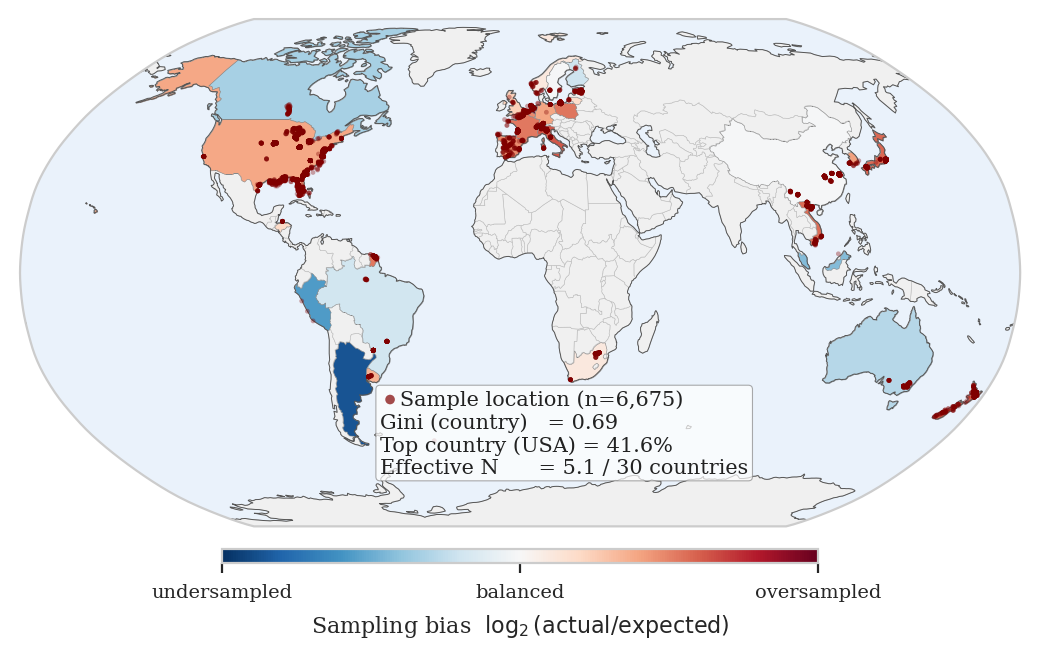

In [12]:
# pip install matplotlib-map-utils geopandas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import geopandas as gpd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable

# =========================
# STYLE — ICML camera-ready
# =========================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

# =========================
# COUNTRY NAME NORMALIZATION
# =========================
# ISO 3166 official names → Natural Earth names
NAME_FIX = {
    'United States of America (the)': 'United States of America',
    'Netherlands (the)': 'Netherlands',
    'United Kingdom of Great Britain and Northern Ireland (the)': 'United Kingdom',
    'Korea (the Republic of)': 'South Korea',
    'Bahamas (the)': 'Bahamas',
    'Viet Nam': 'Vietnam',
    'Russian Federation (the)': 'Russia',
    'Czechia': 'Czech Republic',
    'Iran (Islamic Republic of)': 'Iran',
    'Tanzania, United Republic of': 'Tanzania',
}

def clean_country(name):
    if pd.isna(name):
        return name
    name = NAME_FIX.get(name, name)
    # generic fallback: strip trailing " (the)"
    return name.replace(' (the)', '').strip()

df = df.copy()
df['Country_clean'] = df['Country'].map(clean_country)

# ==========================================================
# COMPUTE PER-COUNTRY BIAS  (actual vs expected by area)
# ==========================================================
country_counts = df.groupby('Country_clean').size().rename('samples')

shp = shpreader.natural_earth(resolution='110m', category='cultural',
                              name='admin_0_countries')
world = gpd.read_file(shp)
world = world[['NAME', 'ADMIN', 'ISO_A3', 'geometry']].copy()

# Equal-area projection for areas
world_eq = world.to_crs('ESRI:54009')
world['area_km2'] = world_eq.area / 1e6

# Match by NAME, then ADMIN as fallback
world['samples'] = (
    world['NAME'].map(country_counts)
    .fillna(world['ADMIN'].map(country_counts))
    .fillna(0)
)

# Sanity check — assigned vs source totals
assigned = world['samples'].sum()
source = country_counts.sum()
print(f"Samples assigned to map: {assigned:,} / {source:,} ({assigned/source*100:.1f}%)")
if assigned < source:
    missing_idx = ~country_counts.index.isin(world['NAME']) & ~country_counts.index.isin(world['ADMIN'])
    print("Still unmatched:", country_counts[missing_idx].to_dict())

total_samples = world['samples'].sum()
total_area = world['area_km2'].sum()
world['expected'] = world['area_km2'] / total_area * total_samples
world['bias'] = np.log2((world['samples'] + 1) / (world['expected'] + 1))

# ==========================================================
# FIGURE — single-panel bias map
# ==========================================================
fig = plt.figure(figsize=(7.0, 3.6), dpi=200)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.OCEAN, facecolor='#eaf2fb', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.35, color='#555', zorder=2)

vmax = float(np.nanpercentile(np.abs(world['bias']), 98))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = plt.get_cmap('RdBu_r')

no_data = world[world['samples'] == 0]
has_data = world[world['samples'] > 0]

ax.add_geometries(
    no_data.geometry, crs=ccrs.PlateCarree(),
    facecolor='#f0f0f0', edgecolor='#bbb', linewidth=0.2, zorder=1
)
for _, row in has_data.iterrows():
    ax.add_geometries(
        [row.geometry], crs=ccrs.PlateCarree(),
        facecolor=cmap(norm(row['bias'])),
        edgecolor='#888', linewidth=0.2, zorder=1
    )

# Overlay sample dots
ax.scatter(
    df['Longitude'], df['Latitude'],
    s=3, c='maroon', alpha=0.35,
    transform=ccrs.PlateCarree(),
    zorder=3, edgecolor='none'
)

# ---- horizontal colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=ax, orientation='horizontal',
    fraction=0.045, pad=0.04, aspect=40, shrink=0.55,
)
cbar.set_label(r'Sampling bias  $\log_2(\mathrm{actual}/\mathrm{expected})$', fontsize=8)
cbar.ax.tick_params(labelsize=7)
cbar.set_ticks([-vmax, 0, vmax])
cbar.set_ticklabels(['undersampled', 'balanced', 'oversampled'])

# ---- stats annotation (top-left)
# ---- stats annotation (top-left) with inline dot legend
top_country = country_counts.idxmax()
top_share = country_counts.max() / country_counts.sum() * 100


stats_text = (
    f"   Sample location (n={len(df):,})\n"
    f"Gini (country)   = 0.69\n"
    f"Top country (USA) = {top_share:.1f}%\n"
    f"Effective N      = 5.1 / 30 countries"
)

ax.text(
    0.36, 0.27, stats_text,
    transform=ax.transAxes,
    fontsize=7.5, va='top', ha='left',
    family='serif', weight='normal',
    color='#222',
    bbox=dict(boxstyle="round,pad=0.2",
              facecolor="white", alpha=0.7,
              edgecolor="#888", linewidth=0.4)
)
# Inline dot proxy aligned with first line
ax.scatter(
    0.37, 0.25,
    s=12, c='maroon', alpha=0.7,
    transform=ax.transAxes,
    zorder=10, edgecolor='none', clip_on=False
)


plt.savefig(OUT / 'fig1_gloria_bias_map.png', dpi=400, bbox_inches='tight')
plt.show()

Samples assigned to map: 6,675.0 / 6,675 (100.0%)


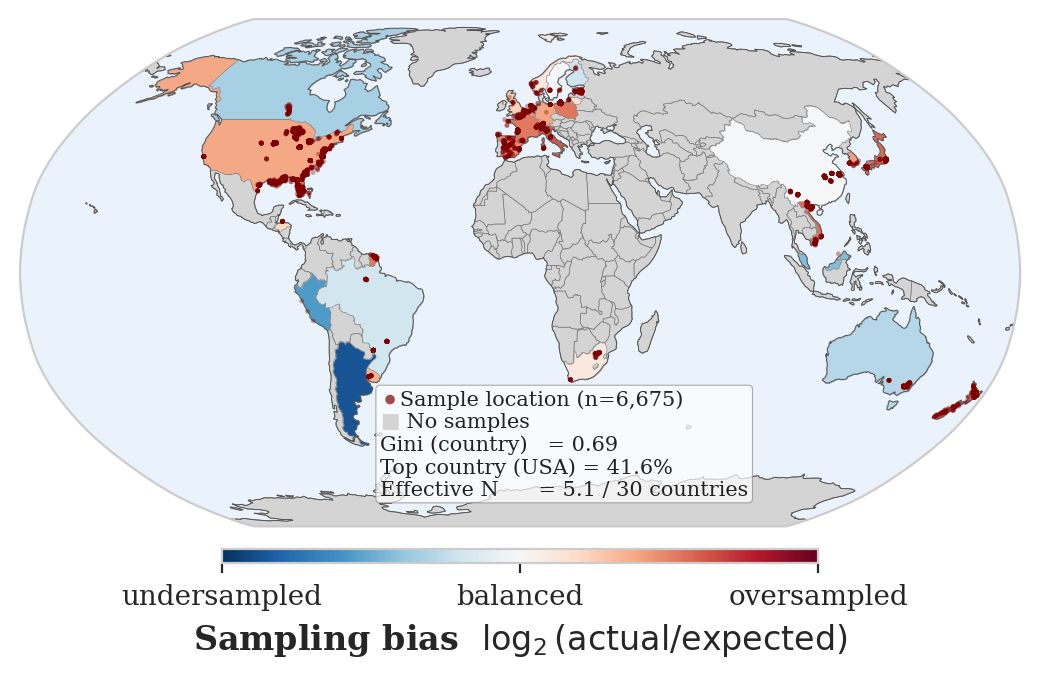

In [13]:
# pip install matplotlib-map-utils geopandas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import geopandas as gpd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable

# =========================
# STYLE — ICML camera-ready
# =========================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# =========================
# COUNTRY NAME NORMALIZATION
# =========================
NAME_FIX = {
    'United States of America (the)': 'United States of America',
    'Netherlands (the)': 'Netherlands',
    'United Kingdom of Great Britain and Northern Ireland (the)': 'United Kingdom',
    'Korea (the Republic of)': 'South Korea',
    'Bahamas (the)': 'Bahamas',
    'Viet Nam': 'Vietnam',
    'Russian Federation (the)': 'Russia',
    'Czechia': 'Czech Republic',
    'Iran (Islamic Republic of)': 'Iran',
    'Tanzania, United Republic of': 'Tanzania',
}

def clean_country(name):
    if pd.isna(name):
        return name
    name = NAME_FIX.get(name, name)
    return name.replace(' (the)', '').strip()

df = df.copy()
df['Country_clean'] = df['Country'].map(clean_country)

# ==========================================================
# COMPUTE PER-COUNTRY BIAS  (actual vs expected by area)
# ==========================================================
country_counts = df.groupby('Country_clean').size().rename('samples')

shp = shpreader.natural_earth(resolution='110m', category='cultural',
                              name='admin_0_countries')
world = gpd.read_file(shp)
world = world[['NAME', 'ADMIN', 'ISO_A3', 'geometry']].copy()

world_eq = world.to_crs('ESRI:54009')
world['area_km2'] = world_eq.area / 1e6

world['samples'] = (
    world['NAME'].map(country_counts)
    .fillna(world['ADMIN'].map(country_counts))
    .fillna(0)
)

assigned = world['samples'].sum()
source = country_counts.sum()
print(f"Samples assigned to map: {assigned:,} / {source:,} ({assigned/source*100:.1f}%)")
if assigned < source:
    missing_idx = ~country_counts.index.isin(world['NAME']) & ~country_counts.index.isin(world['ADMIN'])
    print("Still unmatched:", country_counts[missing_idx].to_dict())

total_samples = world['samples'].sum()
total_area = world['area_km2'].sum()
world['expected'] = world['area_km2'] / total_area * total_samples
world['bias'] = np.log2((world['samples'] + 1) / (world['expected'] + 1))

# Count countries with no samples
n_no_data = int((world['samples'] == 0).sum())
n_total = len(world)

# ==========================================================
# FIGURE — single-panel bias map
# ==========================================================
NO_DATA_COLOR = '#d4d4d4'

fig = plt.figure(figsize=(7.0, 3.6), dpi=200)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.OCEAN, facecolor='#eaf2fb', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.35, color='#555', zorder=2)

vmax = float(np.nanpercentile(np.abs(world['bias']), 98))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = plt.get_cmap('RdBu_r')

no_data = world[world['samples'] == 0]
has_data = world[world['samples'] > 0]

# Highlight countries with no samples
ax.add_geometries(
    no_data.geometry, crs=ccrs.PlateCarree(),
    facecolor=NO_DATA_COLOR, edgecolor='#777',
    linewidth=0.25, zorder=1
)
for _, row in has_data.iterrows():
    ax.add_geometries(
        [row.geometry], crs=ccrs.PlateCarree(),
        facecolor=cmap(norm(row['bias'])),
        edgecolor='#888', linewidth=0.2, zorder=1
    )

# Overlay sample dots
ax.scatter(
    df['Longitude'], df['Latitude'],
    s=3, c='maroon', alpha=0.35,
    transform=ccrs.PlateCarree(),
    zorder=3, edgecolor='none'
)

# ---- horizontal colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=ax, orientation='horizontal',
    fraction=0.045, pad=0.04, aspect=40, shrink=0.55,
)
cbar.set_label(r'Sampling bias  $\log_2(\mathrm{actual}/\mathrm{expected})$',
               fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=10)
cbar.set_ticks([-vmax, 0, vmax])
cbar.set_ticklabels(['undersampled', 'balanced', 'oversampled'])

# ---- stats annotation (top-left) with inline dot legend
top_country = country_counts.idxmax()
top_share = country_counts.max() / country_counts.sum() * 100

# Use a placeholder space where the colored ■ will be overlaid
stats_text = (
    f"   Sample location (n={len(df):,})\n"
    f"    No samples\n"
    f"Gini (country)   = 0.69\n"
    f"Top country (USA) = {top_share:.1f}%\n"
    f"Effective N      = 5.1 / 30 countries"
)

ax.text(
    0.36, 0.27, stats_text,
    transform=ax.transAxes,
    fontsize=7.5, va='top', ha='left',
    family='serif', weight='normal',
    color='#222',
    bbox=dict(boxstyle="round,pad=0.2",
              facecolor="white", alpha=0.7,
              edgecolor="#888", linewidth=0.4)
)

# Inline maroon dot proxy aligned with first line (samples)
ax.scatter(
    0.37, 0.25,
    s=12, c='maroon', alpha=0.7,
    transform=ax.transAxes,
    zorder=10, edgecolor='none', clip_on=False
)

# Inline gray ■ proxy aligned with second line (no samples)
ax.text(
    0.37, 0.21, '■',
    transform=ax.transAxes,
    fontsize=7.5, va='center', ha='center',
    color=NO_DATA_COLOR,
    zorder=10, clip_on=False,
)

plt.savefig(OUT / 'fig1_gloria_bias_map.png', dpi=400, bbox_inches='tight')
plt.show()

In [14]:
# ==========================================================
# DIAGNOSTIC — verify country counts and matching
# ==========================================================
import pandas as pd
import geopandas as gpd
import cartopy.io.shapereader as shpreader

# 1. Raw country counts from your dataframe
country_counts = df.groupby("Country").size().sort_values(ascending=False)
total = country_counts.sum()

print("=" * 60)
print(f"TOTAL SAMPLES: {total:,}")
print("=" * 60)
print("\nTop 10 countries in df:")
for c, n in country_counts.head(10).items():
    print(f"  {n:>7,}  ({n/total*100:5.2f}%)  {c}")

# 2. Check how US is spelled in your df
print("\n" + "=" * 60)
print("All country names containing 'United' or 'States' or 'USA':")
print("=" * 60)
mask = country_counts.index.str.contains("United|States|USA|America", case=False, na=False)
print(country_counts[mask])

# 3. Load Natural Earth and check matching
shp = shpreader.natural_earth(resolution='110m', category='cultural',
                              name='admin_0_countries')
world = gpd.read_file(shp)

df_countries = set(country_counts.index)
ne_names = set(world['NAME']) | set(world['ADMIN'])

matched = df_countries & ne_names
unmatched = df_countries - ne_names

print("\n" + "=" * 60)
print(f"Matched: {len(matched)} / {len(df_countries)} country names")
print("=" * 60)
print(f"\nUnmatched country names from df (samples assigned to nothing):")
for c in sorted(unmatched, key=lambda x: -country_counts[x]):
    print(f"  {country_counts[c]:>7,}  {c!r}")

# 4. Verify the actual top-country share
top_country = country_counts.index[0]
top_n = country_counts.iloc[0]
print("\n" + "=" * 60)
print(f"ACTUAL top country: {top_country!r}")
print(f"  Samples: {top_n:,}")
print(f"  Share:   {top_n/total*100:.2f}%")
print("=" * 60)

TOTAL SAMPLES: 6,675

Top 10 countries in df:
    2,776  (41.59%)  United States of America (the)
      402  ( 6.02%)  China
      382  ( 5.72%)  France
      345  ( 5.17%)  Netherlands (the)
      318  ( 4.76%)  Switzerland
      309  ( 4.63%)  Japan
      303  ( 4.54%)  Italy
      253  ( 3.79%)  New Zealand
      244  ( 3.66%)  Viet Nam
      234  ( 3.51%)  Spain

All country names containing 'United' or 'States' or 'USA':
Country
United States of America (the)                                2776
United Kingdom of Great Britain and Northern Ireland (the)      38
dtype: int64

Matched: 24 / 30 country names

Unmatched country names from df (samples assigned to nothing):
    2,776  'United States of America (the)'
      345  'Netherlands (the)'
      244  'Viet Nam'
       38  'Korea (the Republic of)'
       38  'United Kingdom of Great Britain and Northern Ireland (the)'
        5  'Bahamas (the)'

ACTUAL top country: 'United States of America (the)'
  Samples: 2,776
  Share:   41.5

## 7. Feature engineering — raw bands + 3 physics indices

In [15]:
def band(target_nm):
    return RRS_COLS[int(np.argmin(np.abs(WAVELENGTHS - target_nm)))]

b_blue, b_green, b_red, b_rededge = band(490), band(560), band(665), band(708)
eps = 1e-8
df['idx_blue_green'] = df[b_blue]    / (df[b_green] + eps)
df['idx_red_green']  = df[b_red]     / (df[b_green] + eps)
df['idx_ndci']       = (df[b_rededge] - df[b_red]) / (df[b_rededge] + df[b_red] + eps)

INDEX_COLS = ['idx_blue_green', 'idx_red_green', 'idx_ndci']
FEAT_COLS  = RRS_COLS + INDEX_COLS
print(f'Bands used: blue={b_blue}, green={b_green}, red={b_red}, red-edge={b_rededge}')
print(f'Features: {len(FEAT_COLS)} = {len(RRS_COLS)} Rrs + {len(INDEX_COLS)} indices')

Bands used: blue=Rrs_490, green=Rrs_560, red=Rrs_665, red-edge=Rrs_708
Features: 554 = 551 Rrs + 3 indices


## 8. Per-target preparation

In [16]:
TARGET_CONFIG = {
    'Chla':     {'low': 0.01,  'high': 1000.0, 'unit': 'µg/L',  'label': 'Chl-a'},
    'TSS':      {'low': 0.01,  'high': 1000.0, 'unit': 'mg/L',  'label': 'TSS'},
    'aCDOM440': {'low': 0.001, 'high':   50.0, 'unit': 'm⁻¹',   'label': 'aCDOM(440)'},
}

def prepare_target(df_in, target):
    cfg = TARGET_CONFIG[target]
    sub = df_in[df_in[target].notna()].copy()
    n0 = len(sub)
    sub = sub[(sub[target] > cfg['low']) & (sub[target] < cfg['high'])]
    sub[f'log_{target}'] = np.log(sub[target])
    z = (sub[f'log_{target}'] - sub[f'log_{target}'].mean()) / sub[f'log_{target}'].std()
    sub = sub[z.abs() < 4].reset_index(drop=True)
    print(f'  {target:9s}: {n0:5,d} → {len(sub):5,d} after target QC')
    return sub

print('Target-specific QC:')
target_dfs = {t: prepare_target(df, t) for t in TARGET_CONFIG}

Target-specific QC:
  Chla     : 4,403 → 4,387 after target QC
  TSS      : 4,319 → 4,303 after target QC
  aCDOM440 : 3,813 → 3,807 after target QC


## 9. Modeling utilities — RF + XGBoost

In [17]:
def make_models(seed=RNG):
    return {
        'RF': RandomForestRegressor(
            n_estimators=300, max_depth=None, min_samples_leaf=2,
            n_jobs=-1, random_state=seed),
        'XGB': XGBRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
            random_state=seed, verbosity=0),
    }

def score(y_true_log, y_pred_log):
    return {
        'R2_log':   r2_score(y_true_log, y_pred_log),
        'RMSE_log': np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        'MAE_log':  mean_absolute_error(y_true_log, y_pred_log),
    }

def fit_score(model, tr, te, target_col):
    model.fit(tr[FEAT_COLS].values, tr[target_col].values)
    return score(te[target_col].values, model.predict(te[FEAT_COLS].values))

## 10. Split-strategy runners

Each uses the `Country` / `Region` / `ClimateZone` columns directly from the enriched CSV — no re-mapping inside the notebook.

In [18]:
VALID_ZONES = ['Tropical', 'Arid', 'Temperate', 'Continental']  # exclude Polar (only 1 sample)

def run_random(d, target, n_seeds=10):
    rows = []
    tcol = f'log_{target}'
    for seed in range(n_seeds):
        tr, te = train_test_split(d, test_size=0.2, random_state=seed)
        for name, mdl in make_models(seed).items():
            m = fit_score(mdl, tr, te, tcol)
            m.update(target=target, split='random', fold=f'seed_{seed}', model=name,
                     n_train=len(tr), n_test=len(te))
            rows.append(m)
    return rows

def run_loco(d, target, min_test=30):
    rows = []
    tcol = f'log_{target}'
    cc = d['Country'].value_counts()
    for country in cc[cc >= min_test].index:
        te = d[d['Country'] == country]
        tr = d[d['Country'] != country]
        for name, mdl in make_models(RNG).items():
            m = fit_score(mdl, tr, te, tcol)
            m.update(target=target, split='loco', fold=country, model=name,
                     n_train=len(tr), n_test=len(te))
            rows.append(m)
    return rows

def run_loro(d, target, min_test=50):
    rows = []
    tcol = f'log_{target}'
    rc = d['Region'].value_counts()
    for region in rc.index:
        if region == 'Other' or rc[region] < min_test:
            continue
        te = d[d['Region'] == region]
        tr = d[(d['Region'] != region) & (d['Region'] != 'Other')]
        for name, mdl in make_models(RNG).items():
            m = fit_score(mdl, tr, te, tcol)
            m.update(target=target, split='loro', fold=region, model=name,
                     n_train=len(tr), n_test=len(te))
            rows.append(m)
    return rows

def run_loczo(d, target, min_test=50):
    rows = []
    tcol = f'log_{target}'
    dz = d[d['ClimateZone'].isin(VALID_ZONES)].copy()
    zc = dz['ClimateZone'].value_counts()
    for zone in zc.index:
        if zc[zone] < min_test:
            continue
        te = dz[dz['ClimateZone'] == zone]
        tr = dz[dz['ClimateZone'] != zone]
        dom_pct = te['Region'].value_counts(normalize=True).iloc[0]
        for name, mdl in make_models(RNG).items():
            m = fit_score(mdl, tr, te, tcol)
            m.update(target=target, split='loczo', fold=zone, model=name,
                     n_train=len(tr), n_test=len(te),
                     region_dominance=round(dom_pct, 2))
            rows.append(m)
    return rows

## 11. Split audit — what's actually in each fold?

Verifies the splits BEFORE the 45-min main loop. Each fold should hold out exactly the entity we expect, with the rest going into training.

In [19]:
MIN_TEST_LOCO  = 30
MIN_TEST_LORO  = 50
MIN_TEST_LOCZO = 50

def audit_one_target(d, target):
    rows = []
    # Random: simulate same splits the runner uses, report country diversity
    for seed in range(10):
        tr, te = train_test_split(d, test_size=0.2, random_state=seed)
        rows.append({
            'target': target, 'split': 'random', 'fold': f'seed_{seed}',
            'held_out': '(random row sample)',
            'n_train': len(tr), 'n_test': len(te),
            'n_train_countries': tr['Country'].nunique(),
            'n_test_countries':  te['Country'].nunique(),
            'train_entities': f'{tr["Country"].nunique()} countries (all present)',
        })
    # LOCO
    cc = d['Country'].value_counts()
    for country in cc[cc >= MIN_TEST_LOCO].index:
        te = d[d['Country'] == country]
        tr = d[d['Country'] != country]
        rows.append({
            'target': target, 'split': 'loco', 'fold': country,
            'held_out': country,
            'n_train': len(tr), 'n_test': len(te),
            'n_train_countries': tr['Country'].nunique(),
            'n_test_countries':  1,
            'train_entities': ', '.join(sorted(tr['Country'].unique())),
        })
    # LORO
    rc = d['Region'].value_counts()
    for region in rc.index:
        if region == 'Other' or rc[region] < MIN_TEST_LORO:
            continue
        te = d[d['Region'] == region]
        tr = d[(d['Region'] != region) & (d['Region'] != 'Other')]
        rows.append({
            'target': target, 'split': 'loro', 'fold': region,
            'held_out': region,
            'n_train': len(tr), 'n_test': len(te),
            'n_train_countries': tr['Country'].nunique(),
            'n_test_countries':  te['Country'].nunique(),
            'train_entities': ', '.join(sorted(tr['Region'].unique())),
        })
    # LOCZO
    dz = d[d['ClimateZone'].isin(VALID_ZONES)].copy()
    zc = dz['ClimateZone'].value_counts()
    for zone in zc.index:
        if zc[zone] < MIN_TEST_LOCZO:
            continue
        te = dz[dz['ClimateZone'] == zone]
        tr = dz[dz['ClimateZone'] != zone]
        rows.append({
            'target': target, 'split': 'loczo', 'fold': zone,
            'held_out': zone,
            'n_train': len(tr), 'n_test': len(te),
            'n_train_countries': tr['Country'].nunique(),
            'n_test_countries':  te['Country'].nunique(),
            'train_entities': ', '.join(sorted(tr['ClimateZone'].unique())),
        })
    return rows

audit_rows = []
for t in TARGET_CONFIG:
    audit_rows.extend(audit_one_target(target_dfs[t], t))
audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(OUT/'split_audit_full.csv', index=False)

# Compact summary
compact = (audit_df.groupby(['target','split'])
                  .agg(n_folds=('fold','nunique'),
                       mean_n_train=('n_train','mean'),
                       mean_n_test=('n_test','mean'),
                       mean_train_countries=('n_train_countries','mean'),
                       mean_test_countries=('n_test_countries','mean'))
                  .round(0)
                  .astype(int))
compact.to_csv(OUT/'split_audit_compact.csv')
print('=== COMPACT SPLIT AUDIT ===')
print(compact.to_string())

# Detailed per-fold listing for Chla (other targets have similar structure)
print('\n=== PER-FOLD DETAILS — Chla target ===')
chla = audit_df[audit_df['target']=='Chla']
for split in ['loco','loro','loczo']:
    sub = chla[chla['split']==split].sort_values('n_test', ascending=False)
    print(f'\n--- {split.upper()} ({len(sub)} folds) ---')
    print(sub[['held_out','n_train','n_test',
               'n_train_countries','n_test_countries']]
          .to_string(index=False))

=== COMPACT SPLIT AUDIT ===
                 n_folds  mean_n_train  mean_n_test  mean_train_countries  mean_test_countries
target   split                                                                                
Chla     loco         16          4118          269                    22                    1
         loczo         3          2936         1444                    19                   10
         loro          6          3663          724                    20                    4
         random       10          3509          878                    22                   21
TSS      loco         18          4069          234                    23                    1
         loczo         3          2868         1419                    20                   11
         loro          6          3580          708                    19                    4
         random       10          3442          861                    24                   23
aCDOM440 loco         

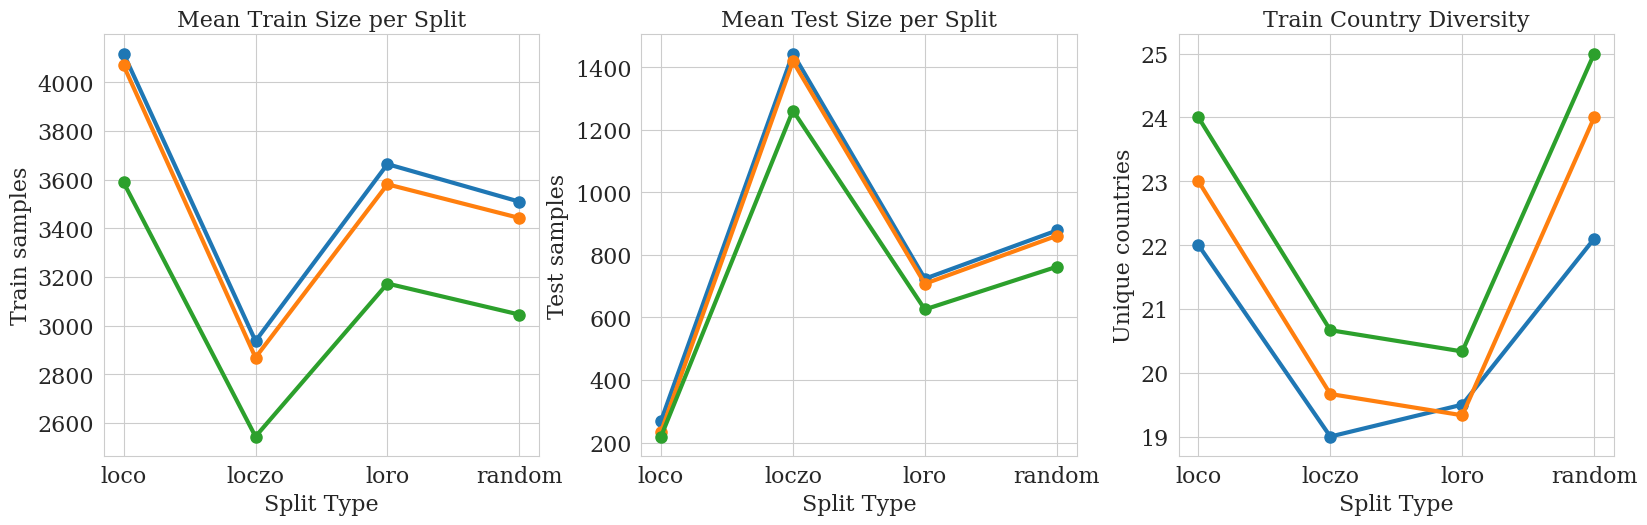

In [20]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16
})
summary = audit_df.groupby(['target', 'split']).agg(
    n_folds=('fold', 'nunique'),
    mean_train=('n_train', 'mean'),
    mean_test=('n_test', 'mean'),
    mean_train_countries=('n_train_countries', 'mean'),
    mean_test_countries=('n_test_countries', 'mean')
).reset_index()

targets = summary['target'].unique()
splits = ['random', 'loco', 'loro', 'loczo']

# fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 6),
    constrained_layout=True
)
# -------------------------
# 1. TRAIN SIZE
# -------------------------
for t in targets:
    sub = summary[summary['target'] == t]
    axes[0].plot(sub['split'], sub['mean_train'], marker='o',linewidth=3, markersize=8)

axes[0].set_title('Mean Train Size per Split')
axes[0].set_xlabel('Split Type')
axes[0].set_ylabel('Train samples')
axes[0].grid(True)

# -------------------------
# 2. TEST SIZE
# -------------------------
for t in targets:
    sub = summary[summary['target'] == t]
    axes[1].plot(sub['split'], sub['mean_test'], marker='o',linewidth=3, markersize=8)

axes[1].set_title('Mean Test Size per Split')
axes[1].set_xlabel('Split Type')
axes[1].set_ylabel('Test samples')
axes[1].grid(True)

# -------------------------
# 3. COUNTRY DIVERSITY (TRAIN)
# -------------------------
for t in targets:
    sub = summary[summary['target'] == t]
    axes[2].plot(sub['split'], sub['mean_train_countries'], marker='o',linewidth=3, markersize=8)

axes[2].set_title('Train Country Diversity')
axes[2].set_xlabel('Split Type')
axes[2].set_ylabel('Unique countries')
axes[2].grid(True)

fig.savefig(
    OUT / "fig_bias.png",
    dpi=500,
    # bbox_inches="tight",
    facecolor="white")
plt.tight_layout()
plt.show()

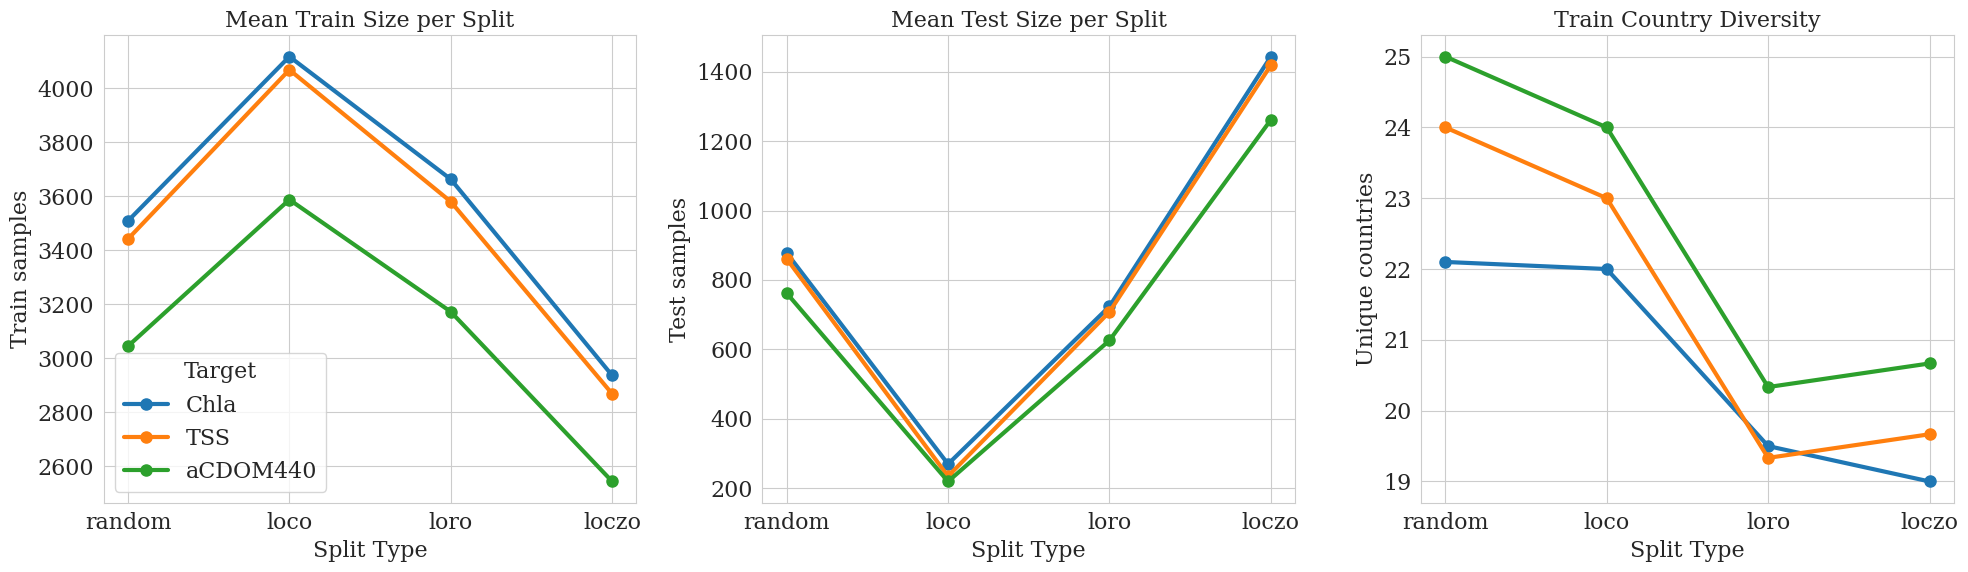

In [21]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16
})

summary = audit_df.groupby(['target', 'split']).agg(
    n_folds=('fold', 'nunique'),
    mean_train=('n_train', 'mean'),
    mean_test=('n_test', 'mean'),
    mean_train_countries=('n_train_countries', 'mean'),
    mean_test_countries=('n_test_countries', 'mean')
).reset_index()

targets = summary['target'].unique()
splits = ['random', 'loco', 'loro', 'loczo']

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 6),
    constrained_layout=True
)

# -------------------------
# 1. TRAIN SIZE
# -------------------------
for t in targets:
    sub = (
        summary[summary['target'] == t]
        .set_index('split')
        .loc[splits]
        .reset_index()
    )

    axes[0].plot(
        sub['split'],
        sub['mean_train'],
        marker='o',
        linewidth=3,
        markersize=8,
        label=t
    )

axes[0].set_title('Mean Train Size per Split')
axes[0].set_xlabel('Split Type')
axes[0].set_ylabel('Train samples')
axes[0].grid(True)

# -------------------------
# 2. TEST SIZE
# -------------------------
for t in targets:
    sub = (
        summary[summary['target'] == t]
        .set_index('split')
        .loc[splits]
        .reset_index()
    )

    axes[1].plot(
        sub['split'],
        sub['mean_test'],
        marker='o',
        linewidth=3,
        markersize=8
    )

axes[1].set_title('Mean Test Size per Split')
axes[1].set_xlabel('Split Type')
axes[1].set_ylabel('Test samples')
axes[1].grid(True)

# -------------------------
# 3. COUNTRY DIVERSITY (TRAIN)
# -------------------------
for t in targets:
    sub = (
        summary[summary['target'] == t]
        .set_index('split')
        .loc[splits]
        .reset_index()
    )

    axes[2].plot(
        sub['split'],
        sub['mean_train_countries'],
        marker='o',
        linewidth=3,
        markersize=8
    )

axes[2].set_title('Train Country Diversity')
axes[2].set_xlabel('Split Type')
axes[2].set_ylabel('Unique countries')
axes[2].grid(True)

axes[0].legend(title="Target")

plt.tight_layout()

fig.savefig(
    OUT / "fig_bias.png",
    dpi=500,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

In [22]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

MIN_TEST_LOCO  = 30
MIN_TEST_LORO  = 50
MIN_TEST_LOCZO = 50

def audit_one_target(d, target):

    rows = []

    # =========================
    # RANDOM SPLITS (baseline)
    # =========================
    for seed in range(10):
        tr, te = train_test_split(d, test_size=0.2, random_state=seed)

        rows.append({
            "target": target,
            "split": "random",
            "fold": f"seed_{seed}",
            "n_train": len(tr),
            "n_test": len(te),

            "train_countries": tr["Country"].nunique(),
            "test_countries": te["Country"].nunique(),

            # diversity metrics
            "country_shift": abs(tr["Country"].nunique() - te["Country"].nunique()),
            "country_overlap": len(set(tr["Country"]) & set(te["Country"])),

            "held_out": "random"
        })

    # =========================
    # LOCO (Leave-One-Country-Out)
    # =========================
    cc = d["Country"].value_counts()

    for country in cc[cc >= MIN_TEST_LOCO].index:

        te = d[d["Country"] == country]
        tr = d[d["Country"] != country]

        rows.append({
            "target": target,
            "split": "loco",
            "fold": country,
            "n_train": len(tr),
            "n_test": len(te),

            "train_countries": tr["Country"].nunique(),
            "test_countries": 1,

            # key: strict domain shift
            "country_shift": tr["Country"].nunique(),
            "country_overlap": 0,

            "held_out": country
        })

    # =========================
    # LORO (Leave-One-Region-Out)
    # =========================
    rc = d["Region"].value_counts()

    for region in rc.index:
        if region == "Other" or rc[region] < MIN_TEST_LORO:
            continue

        te = d[d["Region"] == region]
        tr = d[(d["Region"] != region) & (d["Region"] != "Other")]

        rows.append({
            "target": target,
            "split": "loro",
            "fold": region,
            "n_train": len(tr),
            "n_test": len(te),

            "train_countries": tr["Country"].nunique(),
            "test_countries": te["Country"].nunique(),

            "country_shift": abs(tr["Country"].nunique() - te["Country"].nunique()),
            "country_overlap": len(set(tr["Country"]) & set(te["Country"])),

            "held_out": region
        })

    # =========================
    # LOCZO (Leave-One-Climate-Zone-Out)
    # =========================
    dz = d[d["ClimateZone"].isin(VALID_ZONES)].copy()
    zc = dz["ClimateZone"].value_counts()

    for zone in zc.index:
        if zc[zone] < MIN_TEST_LOCZO:
            continue

        te = dz[dz["ClimateZone"] == zone]
        tr = dz[dz["ClimateZone"] != zone]

        rows.append({
            "target": target,
            "split": "loczo",
            "fold": zone,
            "n_train": len(tr),
            "n_test": len(te),

            "train_countries": tr["Country"].nunique(),
            "test_countries": te["Country"].nunique(),

            "country_shift": abs(tr["Country"].nunique() - te["Country"].nunique()),
            "country_overlap": len(set(tr["Country"]) & set(te["Country"])),

            "held_out": zone
        })

    return rows


# =========================
# RUN FULL AUDIT
# =========================
audit_rows = []

for t in TARGET_CONFIG:
    audit_rows.extend(audit_one_target(target_dfs[t], t))

audit_df = pd.DataFrame(audit_rows)

# =========================
# SAVE FULL RESULTS
# =========================
audit_df.to_csv(OUT / "split_audit_full.csv", index=False)

# =========================
# COMPACT PAPER SUMMARY
# =========================
compact = audit_df.groupby(["target", "split"]).agg(
    n_folds=("fold", "nunique"),
    mean_n_train=("n_train", "mean"),
    mean_n_test=("n_test", "mean"),
    mean_train_countries=("train_countries", "mean"),
    mean_test_countries=("test_countries", "mean"),
    mean_country_shift=("country_shift", "mean"),
    mean_country_overlap=("country_overlap", "mean"),
).round(2)

compact.to_csv(OUT / "split_audit_compact.csv")

print("\n=== COMPACT SPLIT AUDIT (ENHANCED) ===")
print(compact.to_string())

# =========================
# OPTIONAL: QUICK SANITY VIEW
# =========================
print("\n=== SAMPLE ROWS ===")
print(audit_df.head(10))


=== COMPACT SPLIT AUDIT (ENHANCED) ===
                 n_folds  mean_n_train  mean_n_test  mean_train_countries  mean_test_countries  mean_country_shift  mean_country_overlap
target   split                                                                                                                          
Chla     loco         16       4117.81       269.19                 22.00                 1.00               22.00                  0.00
         loczo         3       2936.33      1443.67                 19.00                10.00                9.67                  6.00
         loro          6       3663.33       723.67                 19.50                 3.50               16.00                  0.00
         random       10       3509.00       878.00                 22.10                20.90                1.40                 20.00
TSS      loco         18       4068.89       234.11                 23.00                 1.00               23.00                  0.00
 

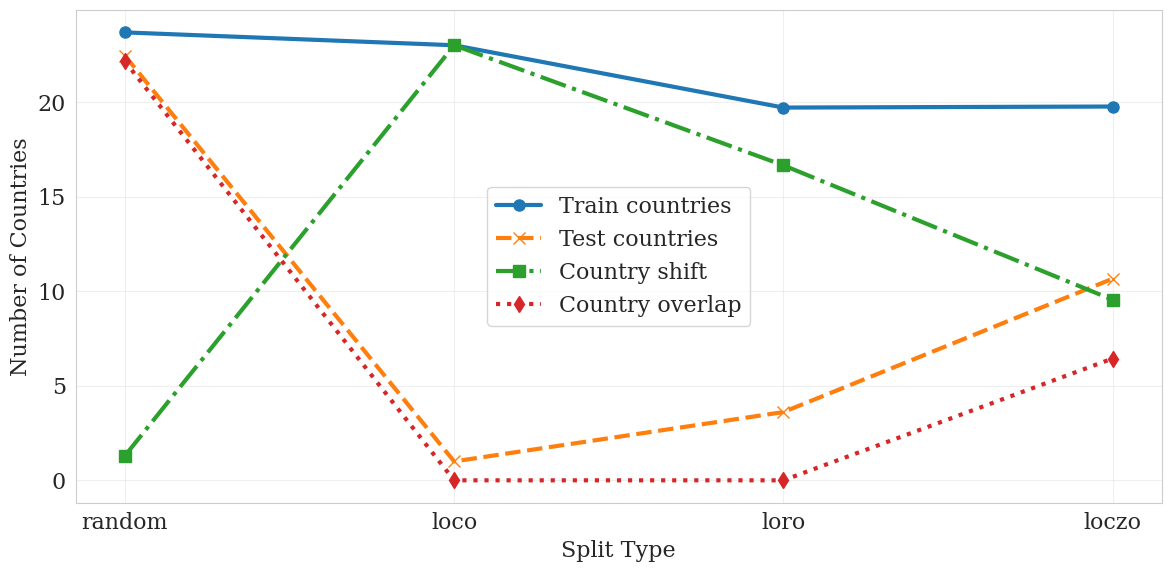

In [23]:
import matplotlib.pyplot as plt

summary = audit_df.groupby(["split"]).agg(
    train_countries=("train_countries", "mean"),
    test_countries=("test_countries", "mean"),
    overlap=("country_overlap", "mean"),
    shift=("country_shift", "mean"),
).reset_index()

splits_order = ["random", "loco", "loro", "loczo"]
summary = summary.set_index("split").loc[splits_order].reset_index()

# ------------------------
# GLOBAL STYLE (IMPORTANT)
# ------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16
})

fig, ax = plt.subplots(figsize=(12, 6))

# ------------------------
# LINES (thicker + clearer)
# ------------------------

ax.plot(summary["split"], summary["train_countries"],
        marker="o", linewidth=3, markersize=8,
        label="Train countries")

ax.plot(summary["split"], summary["test_countries"],
        marker="x", linestyle="--", linewidth=3, markersize=8,
        label="Test countries")

ax.plot(summary["split"], summary["shift"],
        marker="s", linestyle="-.", linewidth=3, markersize=8,
        label="Country shift")

ax.plot(summary["split"], summary["overlap"],
        marker="d", linestyle=":", linewidth=3, markersize=8,
        label="Country overlap")

# ------------------------
# AXES STYLE
# ------------------------
ax.set_xlabel("Split Type")
ax.set_ylabel("Number of Countries")

ax.grid(True, alpha=0.3)

ax.legend(frameon=True, fancybox=True, shadow=False)
fig.savefig(
    OUT / "fig_split.png",
    dpi=500,
    bbox_inches="tight",
    facecolor="white"
)
plt.tight_layout()
plt.show()

## 12. Main loop — all targets × all splits × both models

Saves progress after each (target, split) pair. Resumable: if kernel dies, just re-run — `SKIP_EXISTING=True` will pick up where it left off.

In [24]:
SKIP_EXISTING = True
PROGRESS_PATH = OUT/'multi_target_results.csv'

if PROGRESS_PATH.exists() and SKIP_EXISTING:
    prior = pd.read_csv(PROGRESS_PATH)
    done_pairs = set(zip(prior['target'], prior['split']))
    print(f'Resuming: {len(prior)} prior rows; completed pairs: {len(done_pairs)}')
    all_rows = prior.to_dict('records')
else:
    done_pairs = set()
    all_rows = []
    print('Starting fresh.')

RUNNERS = {'random': run_random, 'loco': run_loco, 'loro': run_loro, 'loczo': run_loczo}

t_overall = time.time()
for target in TARGET_CONFIG:
    dt = target_dfs[target]
    print(f'\n=== TARGET: {target} (n={len(dt):,}) ===')
    for split_name, runner in RUNNERS.items():
        if (target, split_name) in done_pairs:
            print(f'  [skip] {split_name}')
            continue
        t0 = time.time()
        new_rows = runner(dt, target)
        all_rows.extend(new_rows)
        pd.DataFrame(all_rows).to_csv(PROGRESS_PATH, index=False)
        print(f'  {split_name:6s} → {len(new_rows)} folds in {time.time()-t0:5.1f}s')

print(f'\nTotal: {(time.time()-t_overall)/60:.1f} min')
print(f'Wrote {PROGRESS_PATH}')

Resuming: 216 prior rows; completed pairs: 12

=== TARGET: Chla (n=4,387) ===
  [skip] random
  [skip] loco
  [skip] loro
  [skip] loczo

=== TARGET: TSS (n=4,303) ===
  [skip] random
  [skip] loco
  [skip] loro
  [skip] loczo

=== TARGET: aCDOM440 (n=3,807) ===
  [skip] random
  [skip] loco
  [skip] loro
  [skip] loczo

Total: 0.0 min
Wrote outputs\multi_target_results.csv


## 13. Unified results summary

In [25]:
res = pd.DataFrame(all_rows)
print(f'Total rows: {len(res):,}')

# Continental zone is geographically confounded with North America (~98%) — exclude from LOCZO summary
res_clean = res[~((res['split']=='loczo') & (res['fold']=='Continental'))]

summary = (res_clean.groupby(['target','split','model'])
                   .agg(R2_mean=('R2_log','mean'),
                        R2_std=('R2_log','std'),
                        RMSE_mean=('RMSE_log','mean'),
                        n_folds=('R2_log','size'))
                   .round(3))
summary.to_csv(OUT/'multi_target_summary.csv')
print('=== UNIFIED SUMMARY (Continental excluded from LOCZO) ===')
print(summary)

Total rows: 216
=== UNIFIED SUMMARY (Continental excluded from LOCZO) ===
                       R2_mean  R2_std  RMSE_mean  n_folds
target   split  model                                     
Chla     loco   RF       0.386   0.879      0.762       16
                XGB      0.528   0.379      0.741       16
         loczo  RF       0.716   0.003      0.839        2
                XGB      0.741   0.007      0.800        2
         loro   RF       0.711   0.104      0.816        6
                XGB      0.718   0.098      0.808        6
         random RF       0.880   0.014      0.554       10
                XGB      0.885   0.010      0.544       10
TSS      loco   RF       0.262   0.780      0.912       18
                XGB      0.193   1.004      0.925       18
         loczo  RF       0.439   0.104      1.203        2
                XGB      0.407   0.128      1.237        2
         loro   RF       0.487   0.306      0.938        6
                XGB      0.438   0.286   

## 14. Headline table — XGB and RF, target × split

In [26]:
split_order  = ['random','loczo','loro','loco']
target_order = ['Chla','TSS','aCDOM440']

for model in ['XGB', 'RF']:
    wide = (res_clean[res_clean['model']==model]
            .groupby(['target','split'])['R2_log'].mean()
            .unstack('split')[split_order]
            .reindex(target_order)
            .round(3))
    wide.columns = ['Random','LOCZO','LORO','LOCO']
    wide.to_csv(OUT/f'table_headline_{model.lower()}.csv')
    print(f'=== {model} — R²(log) by target and split ===')
    print(wide.to_string()); print()

=== XGB — R²(log) by target and split ===
          Random  LOCZO   LORO   LOCO
target                               
Chla       0.885  0.741  0.718  0.528
TSS        0.696  0.407  0.438  0.193
aCDOM440   0.616  0.352 -0.042 -0.146

=== RF — R²(log) by target and split ===
          Random  LOCZO   LORO   LOCO
target                               
Chla       0.880  0.716  0.711  0.386
TSS        0.685  0.439  0.487  0.262
aCDOM440   0.614  0.353 -0.152 -0.190



## 15. Headline figure — per-fold R² distribution

Shows the actual distribution of fold-level R² values for each (target, split, model) combination. Box = IQR across folds, dots = individual folds. This is more honest than error bars from groupby std, because the "std" means different things across splits (10 seeds vs 6 regions vs 16 countries).

C:\Users\sksus\AppData\Local\Temp\ipykernel_15368\2193173542.py:113: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\sksus\AppData\Local\Temp\ipykernel_15368\2193173542.py:113: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


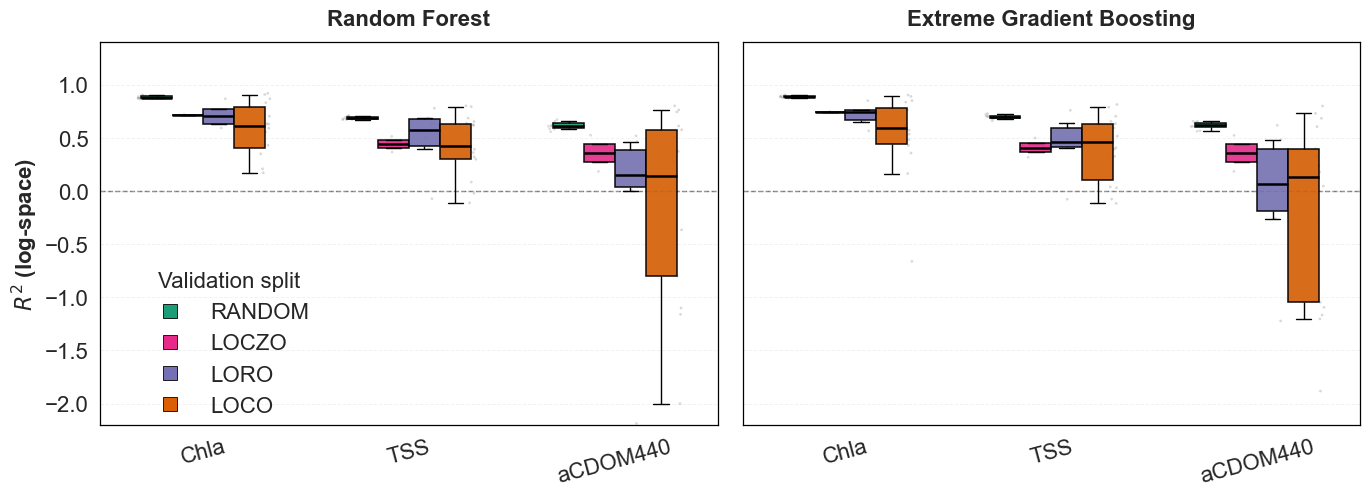

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# =========================================================
# GLOBAL STYLE
# =========================================================
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2
)

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.9,
    "grid.color": "#d9d9d9",
    "grid.linestyle": "--",
    "grid.linewidth": 0.7
})

# =========================================================
# COLOR PALETTE
# =========================================================
palette = {
    "random": "#1b9e77",
    "loco":   "#d95f02",
    "loro":   "#7570b3",
    "loczo":  "#e7298a"
}

# =========================================================
# MODEL LABELS
# =========================================================
model_labels = {
    "RF":  "Random Forest",
    "XGB": "Extreme Gradient Boosting"
}
colors = sns.color_palette('viridis', n_colors=len(split_order))
# =========================================================
# AXIS LIMITS
# =========================================================
y_lower = -2.2
y_upper = 1.4

# =========================================================
# FIGURE
# =========================================================
fig, axes = plt.subplots(
    ncols=2,
    figsize=(14, 5.8),
    sharey=True
)

# Better subplot spacing
fig.subplots_adjust(
    top=0.82,
    bottom=0.16,
    left=0.08,
    right=0.98,
    wspace=0.04
)

# =========================================================
# MAIN LOOP
# =========================================================
for ax, (model_code, model_name) in zip(axes, model_labels.items()):

    sub = res_clean.query("model == @model_code").copy()

    # -----------------------------------------------------
    # BOXPLOT
    # -----------------------------------------------------
    sns.boxplot(
        data=sub,
        x="target",
        y="R2_log",
        hue="split",
        order=target_order,
        hue_order=split_order,
        palette=palette,
        width=0.60,
        dodge=True,
        whis=(5, 95),
        showfliers=False,
        saturation=0.95,
        linewidth=1.15,
        boxprops=dict(
            edgecolor="black",
            alpha=0.92
        ),
        whiskerprops=dict(
            color="black",
            linewidth=1.0
        ),
        capprops=dict(
            color="black",
            linewidth=1.0
        ),
        medianprops=dict(
            color="black",
            linewidth=1.8
        ),
        ax=ax
    )

    # -----------------------------------------------------
    # RAW DATA OVERLAY
    # -----------------------------------------------------
    sns.stripplot(
        data=sub,
        x="target",
        y="R2_log",
        hue="split",
        order=target_order,
        hue_order=split_order,
        dodge=True,
        jitter=0.10,
        size=2.0,
        alpha=0.15,
        color="black",
        linewidth=0,
        zorder=1,
        ax=ax
    )

    # Remove duplicate legends from seaborn
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # -----------------------------------------------------
    # TITLES
    # -----------------------------------------------------
    ax.set_title(
        model_name,
        fontsize=16,
        pad=12
    )

    # -----------------------------------------------------
    # LABELS
    # -----------------------------------------------------
    ax.set_xlabel("")

    if model_code == "RF":
        ax.set_ylabel(
            r"$R^2$ (log-space)",
            fontsize=16
        )
    else:
        ax.set_ylabel("")

    # -----------------------------------------------------
    # REFERENCE LINE
    # -----------------------------------------------------
    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.55,
        zorder=0
    )

    # -----------------------------------------------------
    # AXIS LIMITS
    # -----------------------------------------------------
    ax.set_ylim(y_lower, y_upper)

    # -----------------------------------------------------
    # TICKS
    # -----------------------------------------------------
    ax.tick_params(
        axis="x",
        labelrotation=15,
        labelsize=16
    )

    ax.tick_params(
        axis="y",
        labelsize=16
    )

    # -----------------------------------------------------
    # GRID
    # -----------------------------------------------------
    ax.grid(
        axis="y",
        alpha=0.35
    )

    ax.grid(
        axis="x",
        visible=False
    )

    # -----------------------------------------------------
    # FULL SPINES
    # -----------------------------------------------------
    for side in ["left", "right", "top", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("black")
        ax.spines[side].set_linewidth(0.9)

# =========================================================
# SHARED LEGEND
# =========================================================
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="",
        markersize=10,
        markerfacecolor=palette[key],
        markeredgecolor="black",
        markeredgewidth=0.6,
        label=key.upper()
    )
    for key in split_order
]

fig.legend(
    handles=legend_handles,
    title="Validation split",
    ncol=1,
    loc="center left",
    bbox_to_anchor=(0.1, 0.3),
    frameon=False,
    fontsize=16,
    title_fontsize=16
)

# =========================================================
# GLOBAL TITLE
# =========================================================
# fig.suptitle(
#     "Per-Fold Generalization Performance Across Validation Protocols",
#     fontsize=18,
#     fontweight="bold",
#     y=0.98
# )

# =========================================================
# SAVE FIGURE
# =========================================================
fig.savefig(
    OUT / "fig_boxplot_clean.png",
    dpi=500,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

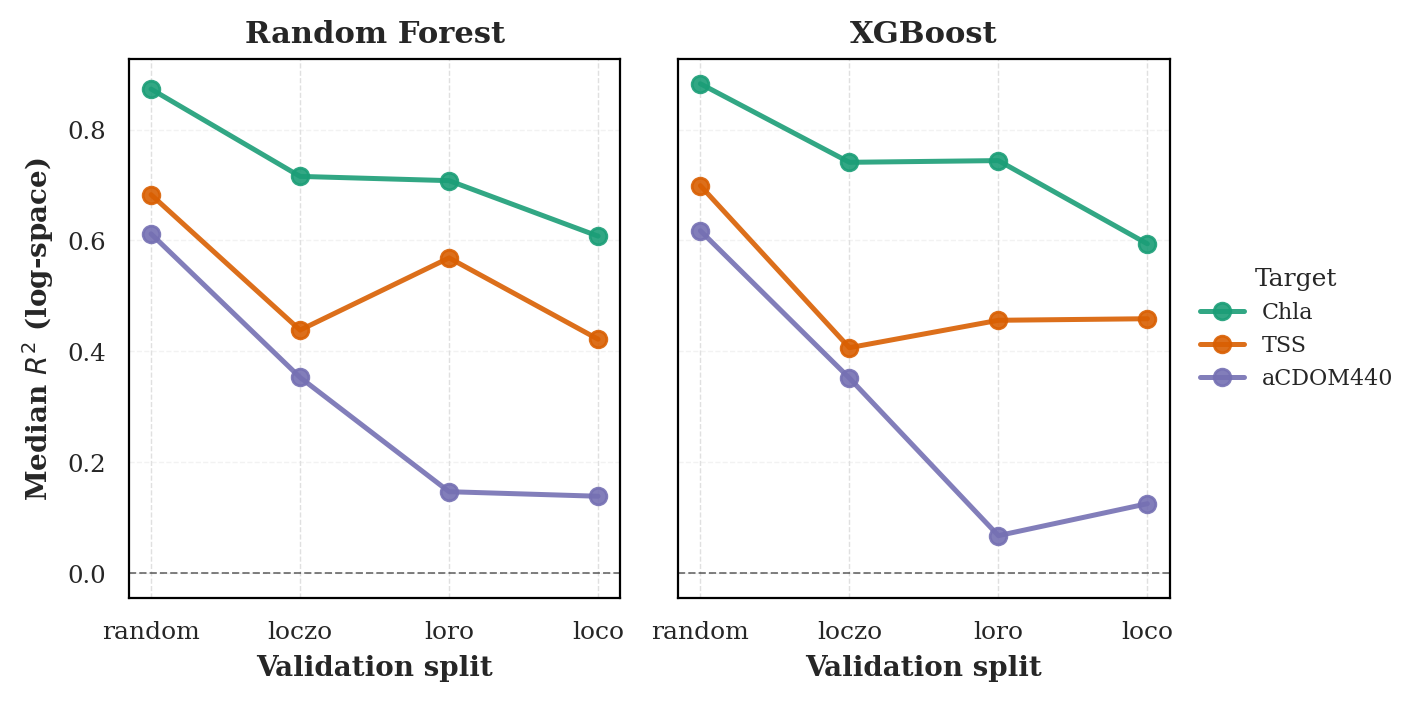

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({"font.family": "serif"})

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.6), sharey=True, dpi=200)

target_colors = sns.color_palette("Dark2", n_colors=len(target_order))

for ax, model_code in zip(axes, ["RF", "XGB"]):
    sub = res_clean.query("model == @model_code")
    medians = (
        sub.groupby(["target", "split"])["R2_log"]
        .median().unstack("split")[split_order]
    )

    x = np.arange(len(split_order))
    for i, target in enumerate(target_order):
        if target not in medians.index:
            continue
        y = medians.loc[target].values
        ax.plot(x, y, marker='o', markersize=6,
                linewidth=1.8, color=target_colors[i],
                label=target, alpha=0.9)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(split_order, fontsize=9)
    ax.set_title({"RF": "Random Forest", "XGB": "XGBoost"}[model_code],
                 fontsize=11, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xlabel("Validation split", fontsize=10)

axes[0].set_ylabel(r"Median $R^2$ (log-space)", fontsize=10)
axes[1].legend(title="Target", loc='center left',
               bbox_to_anchor=(1.02, 0.5), fontsize=8,
               title_fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(OUT / "fig_slopegraph.pdf", bbox_inches='tight')
plt.savefig(OUT / "fig_slopegraph.png", dpi=400, bbox_inches='tight')
plt.show()

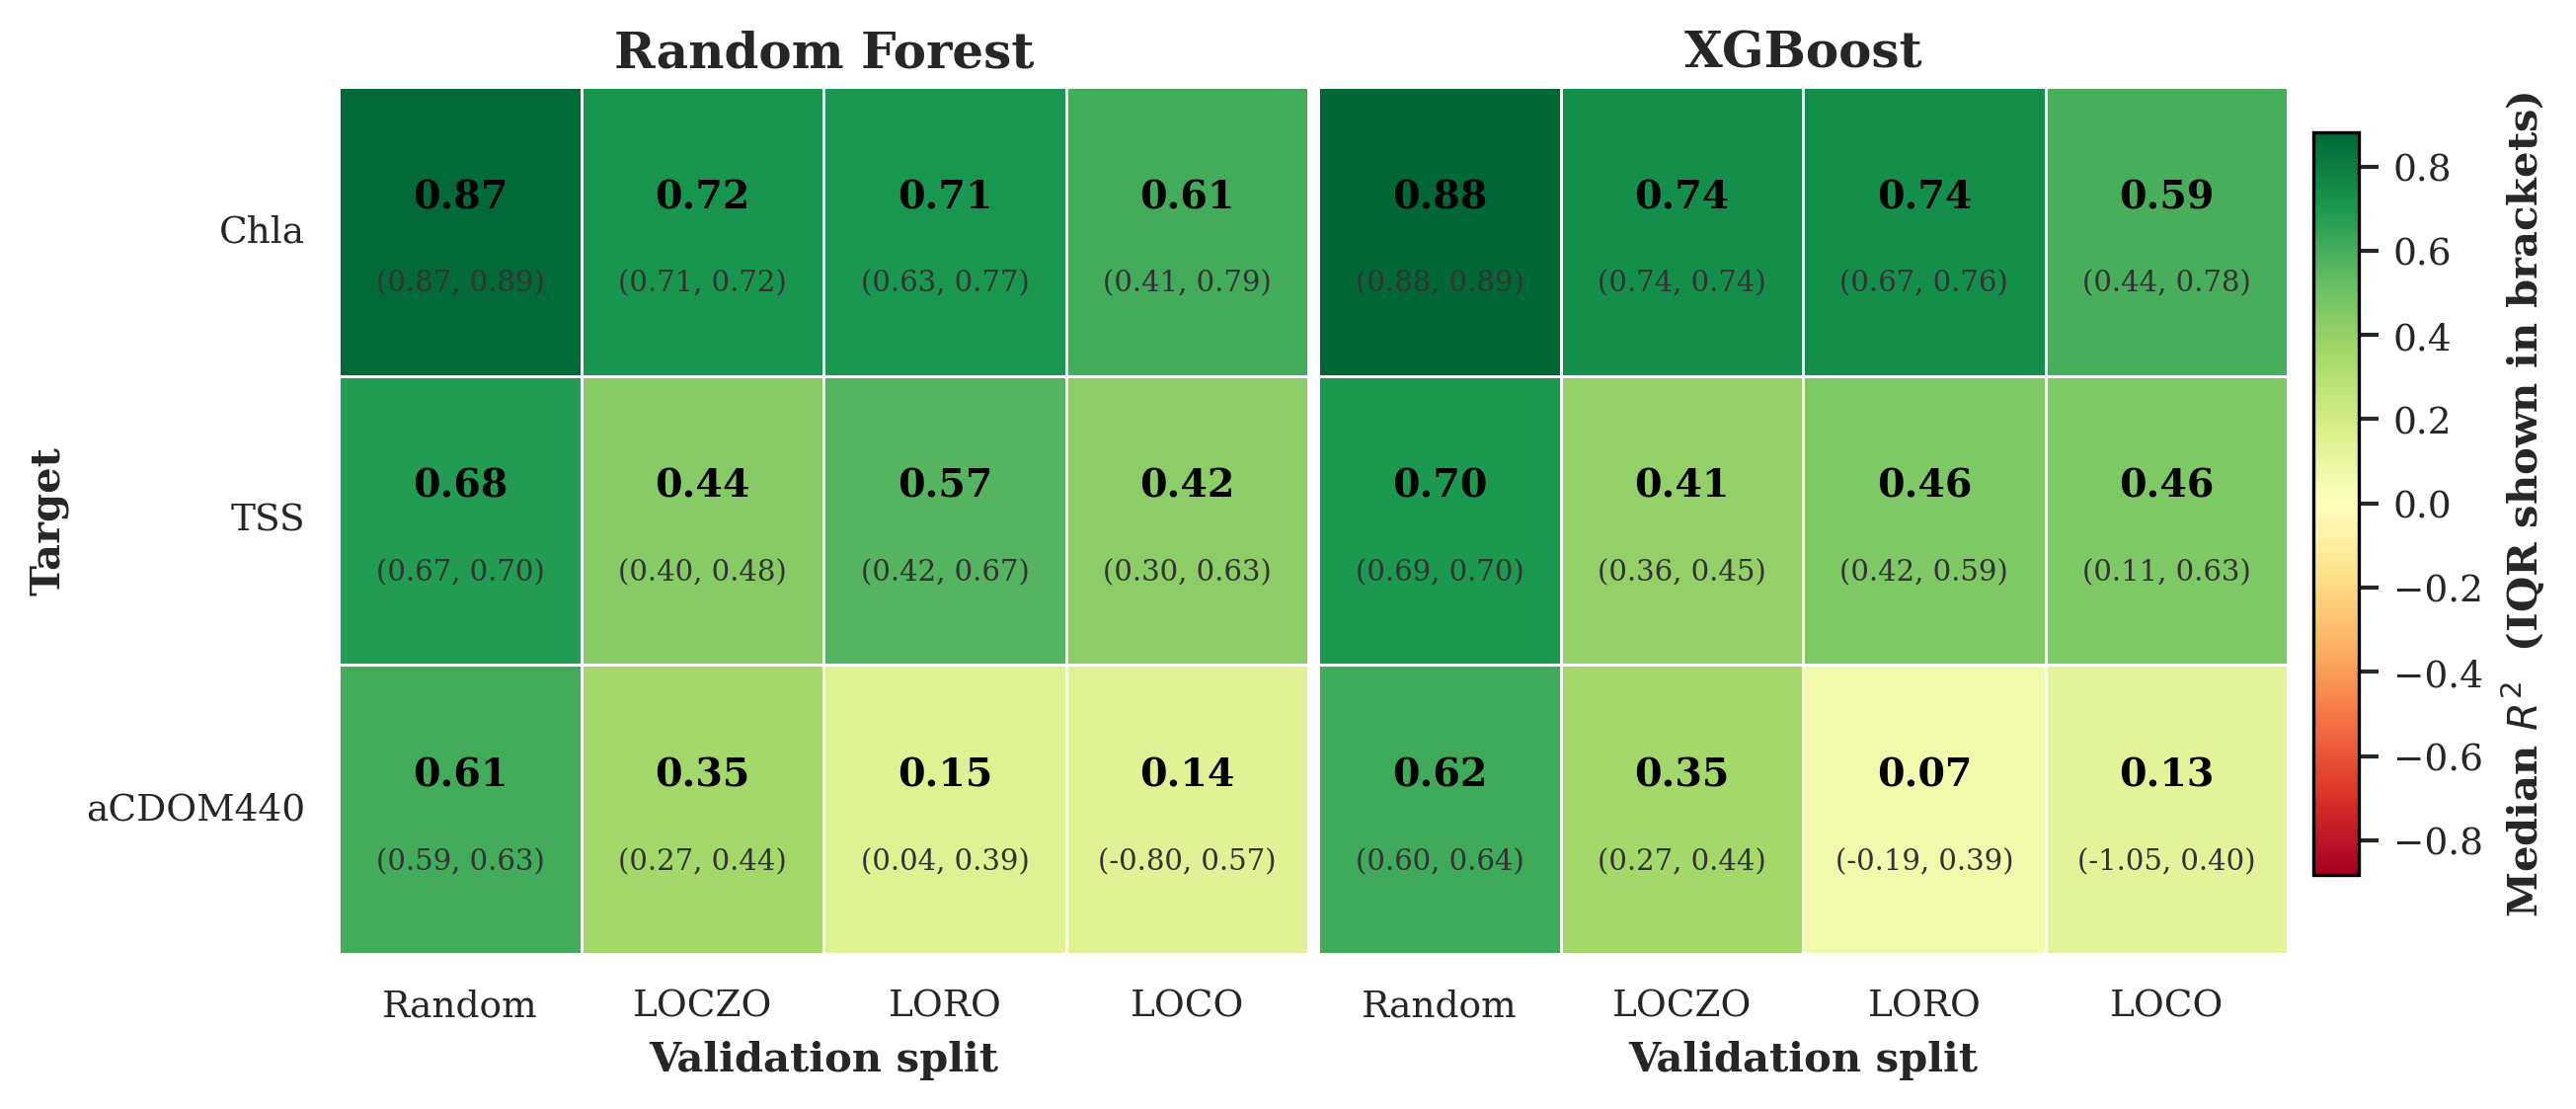

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
})

split_pretty = {"random": "Random", "loco": "LOCO",
                "loro": "LORO", "loczo": "LOCZO"}
model_pretty = {"RF": "Random Forest", "XGB": "XGBoost"}

fig, axes = plt.subplots(
    1, 2, figsize=(8.6, 3.8), sharey=True, dpi=300,
    gridspec_kw={"width_ratios": [1, 1], "wspace": 0.01},
)

all_meds = (
    res_clean.groupby(["model", "target", "split"])["R2_log"]
    .median().values
)
vabs = float(np.nanmax(np.abs(all_meds)))
vmin, vmax = -vabs, vabs

for i, (ax, model_code) in enumerate(zip(axes, ["RF", "XGB"])):
    sub = res_clean.query("model == @model_code")

    med = (sub.groupby(["target", "split"])["R2_log"]
              .median().unstack("split")
              .reindex(index=target_order, columns=split_order))
    q25 = (sub.groupby(["target", "split"])["R2_log"]
              .quantile(0.25).unstack("split")
              .reindex(index=target_order, columns=split_order))
    q75 = (sub.groupby(["target", "split"])["R2_log"]
              .quantile(0.75).unstack("split")
              .reindex(index=target_order, columns=split_order))

    med.columns = [split_pretty.get(c, c) for c in med.columns]

    sns.heatmap(
        med, ax=ax, cmap="RdYlGn", center=0,
        vmin=vmin, vmax=vmax, annot=False, cbar=False,
        linewidths=0.6, linecolor='white', square=False,
    )

    # Custom annotations: median (bold) + IQR (smaller)
    for r in range(med.shape[0]):
        for c in range(med.shape[1]):
            m = med.iat[r, c]
            lo = q25.iat[r, c]
            hi = q75.iat[r, c]
            if np.isnan(m):
                continue
            ax.text(c + 0.5, r + 0.38, f"{m:.2f}",
                    ha='center', va='center',
                    fontsize=9.5, fontweight='bold', color='black')
            ax.text(c + 0.5, r + 0.68, f"({lo:.2f}, {hi:.2f})",
                    ha='center', va='center',
                    fontsize=7, color='#333')

    ax.set_title(model_pretty[model_code], fontsize=12, pad=5)
    ax.set_xlabel("Validation split", fontsize=10)
    ax.set_ylabel("Target" if i == 0 else "", fontsize=10)
    ax.tick_params(axis='x', labelrotation=0, labelsize=9,
                   left=False, bottom=False)
    ax.tick_params(axis='y', labelrotation=0, labelsize=9,
                   left=False, bottom=False)

# Shared colorbar
fig.subplots_adjust(right=0.89)
cbar_ax = fig.add_axes([0.90, 0.18, 0.018, 0.66])
sm = plt.cm.ScalarMappable(cmap="RdYlGn",
                           norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r"Median $R^2$  (IQR shown in brackets)", fontsize=10)
cbar.ax.tick_params(labelsize=9)


plt.savefig(OUT / "fig_heatmap_iqr.png", dpi=500, bbox_inches='tight')
plt.show()

## 16. Key finding check — does LOCO < LORO hold for all targets?

In [33]:
print('=== KEY FINDING CHECK ===\n')
for target in target_order:
    print(f'--- {target} ---')
    for model in ['RF','XGB']:
        sub = res_clean[(res_clean['target']==target) & (res_clean['model']==model)]
        r = {s: sub[sub['split']==s]['R2_log'].mean() for s in split_order}
        line = f'  {model}: random {r["random"]:.3f}  >  loczo {r["loczo"]:.3f}  '
        line += f'>  loro {r["loro"]:.3f}  >  loco {r["loco"]:.3f}'
        print(line)
        gap = r['loro'] - r['loco']
        mark = '✓' if r['loco'] < r['loro'] else '✗'
        print(f'        {mark} LOCO vs LORO gap = {gap:+.3f}')
    print()

print('\nFiles in outputs/:')
for p in sorted(OUT.glob('*')):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:40s} {size_kb:7.1f} KB')

=== KEY FINDING CHECK ===

--- Chla ---
  RF: random 0.880  >  loczo 0.716  >  loro 0.711  >  loco 0.386
        ✓ LOCO vs LORO gap = +0.325
  XGB: random 0.885  >  loczo 0.741  >  loro 0.718  >  loco 0.528
        ✓ LOCO vs LORO gap = +0.189

--- TSS ---
  RF: random 0.685  >  loczo 0.439  >  loro 0.487  >  loco 0.262
        ✓ LOCO vs LORO gap = +0.225
  XGB: random 0.696  >  loczo 0.407  >  loro 0.438  >  loco 0.193
        ✓ LOCO vs LORO gap = +0.245

--- aCDOM440 ---
  RF: random 0.614  >  loczo 0.353  >  loro -0.152  >  loco -0.190
        ✓ LOCO vs LORO gap = +0.039
  XGB: random 0.616  >  loczo 0.352  >  loro -0.042  >  loco -0.146
        ✓ LOCO vs LORO gap = +0.104


Files in outputs/:
  .ipynb_checkpoints                           4.0 KB
  clean_split_structure.csv                    0.3 KB
  correct_split_structure.csv                  0.3 KB
  fig1_gloria_bias_map.pdf                   299.6 KB
  fig1_gloria_bias_map.png                   489.6 KB
  fig1_gloria_world_map.p

## 17. Poster additions — Lorenz curve (Gini) + k-fold leakage diagram

df in scope: 6675 rows (should be 6,675 for Gini=0.69)
Gini = 0.69, Neff = 10.5 / 30


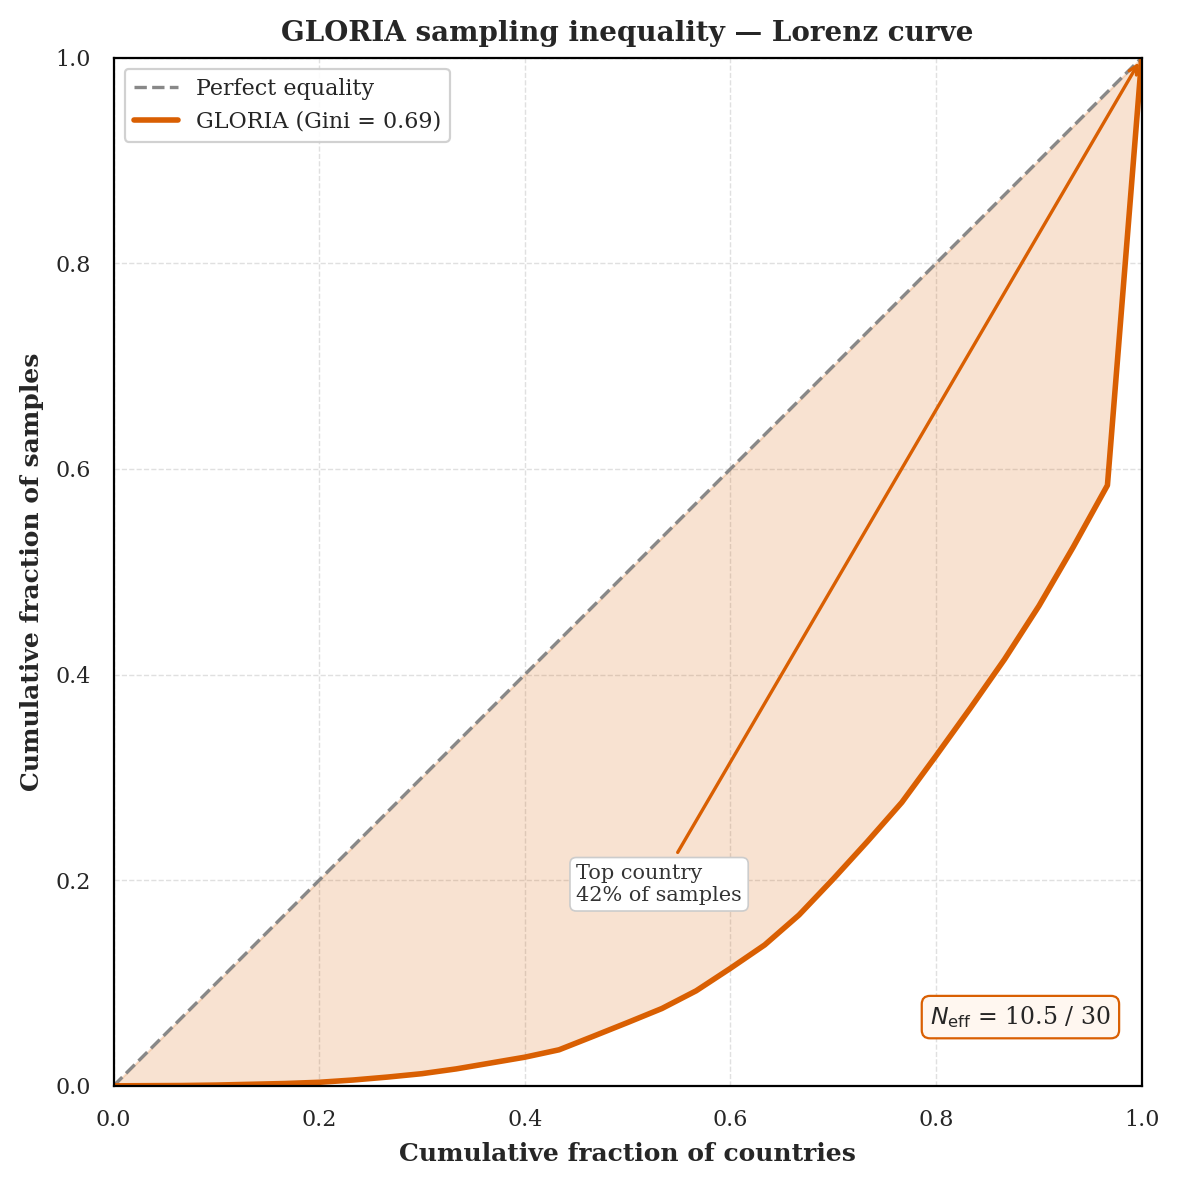

Saved: fig_lorenz.png


In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

print(f"df in scope: {len(df)} rows (should be 6,675 for Gini=0.69)")

fig1, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=200)

country_counts = df['Country'].value_counts().sort_values()
n_countries = len(country_counts)
counts = country_counts.values.astype(float)

cum_counts = np.cumsum(counts) / counts.sum()
cum_pop    = np.arange(1, n_countries + 1) / n_countries
lorenz_x = np.concatenate([[0], cum_pop])
lorenz_y = np.concatenate([[0], cum_counts])

gini = 1 - 2 * np.trapezoid(lorenz_y, lorenz_x)

# Perfect equality line
ax.plot([0, 1], [0, 1], '--', color='#888', linewidth=1.2, label='Perfect equality')

# Shaded area
ax.fill_between(lorenz_x, lorenz_y, lorenz_x, alpha=0.18, color='#d95f02')

# Lorenz curve
ax.plot(lorenz_x, lorenz_y, color='#d95f02', linewidth=2.0,
        label=f'GLORIA (Gini = {gini:.2f})')

# Arrow pointing to the steepest jump (dominant country)
jump_idx = np.argmax(np.diff(lorenz_y))
arrow_x  = lorenz_x[jump_idx + 1]
arrow_y  = lorenz_y[jump_idx + 1]

usa_key = [k for k in df['Country'].value_counts(normalize=True).index
           if 'United States' in str(k)]
usa_share = df['Country'].value_counts(normalize=True)[usa_key[0]] if usa_key else 0.42

ax.annotate(
    f'Top country\n{usa_share*100:.0f}% of samples',
    xy=(arrow_x, arrow_y),
    xytext=(0.45, 0.18),
    arrowprops=dict(arrowstyle='->', color='#d95f02', lw=1.2),
    fontsize=7.5, color='#333',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc', lw=0.6)
)

# Neff box
H    = -np.sum((counts/counts.sum()) * np.log(counts/counts.sum() + 1e-12))
neff = np.exp(H)
print(f"Gini = {gini:.2f}, Neff = {neff:.1f} / {n_countries}")

ax.text(0.97, 0.06,
        f'$N_{{\\mathrm{{eff}}}}$ = {neff:.1f} / {n_countries}',
        transform=ax.transAxes, fontsize=8.5, ha='right',
        bbox=dict(boxstyle='round,pad=0.35', fc='#fff7f0', ec='#d95f02', lw=0.8))

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Cumulative fraction of countries')
ax.set_ylabel('Cumulative fraction of samples')
ax.set_title('GLORIA sampling inequality — Lorenz curve')
ax.legend(loc='upper left', frameon=True, framealpha=0.9)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(OUT / 'fig_lorenz.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_lorenz.png')

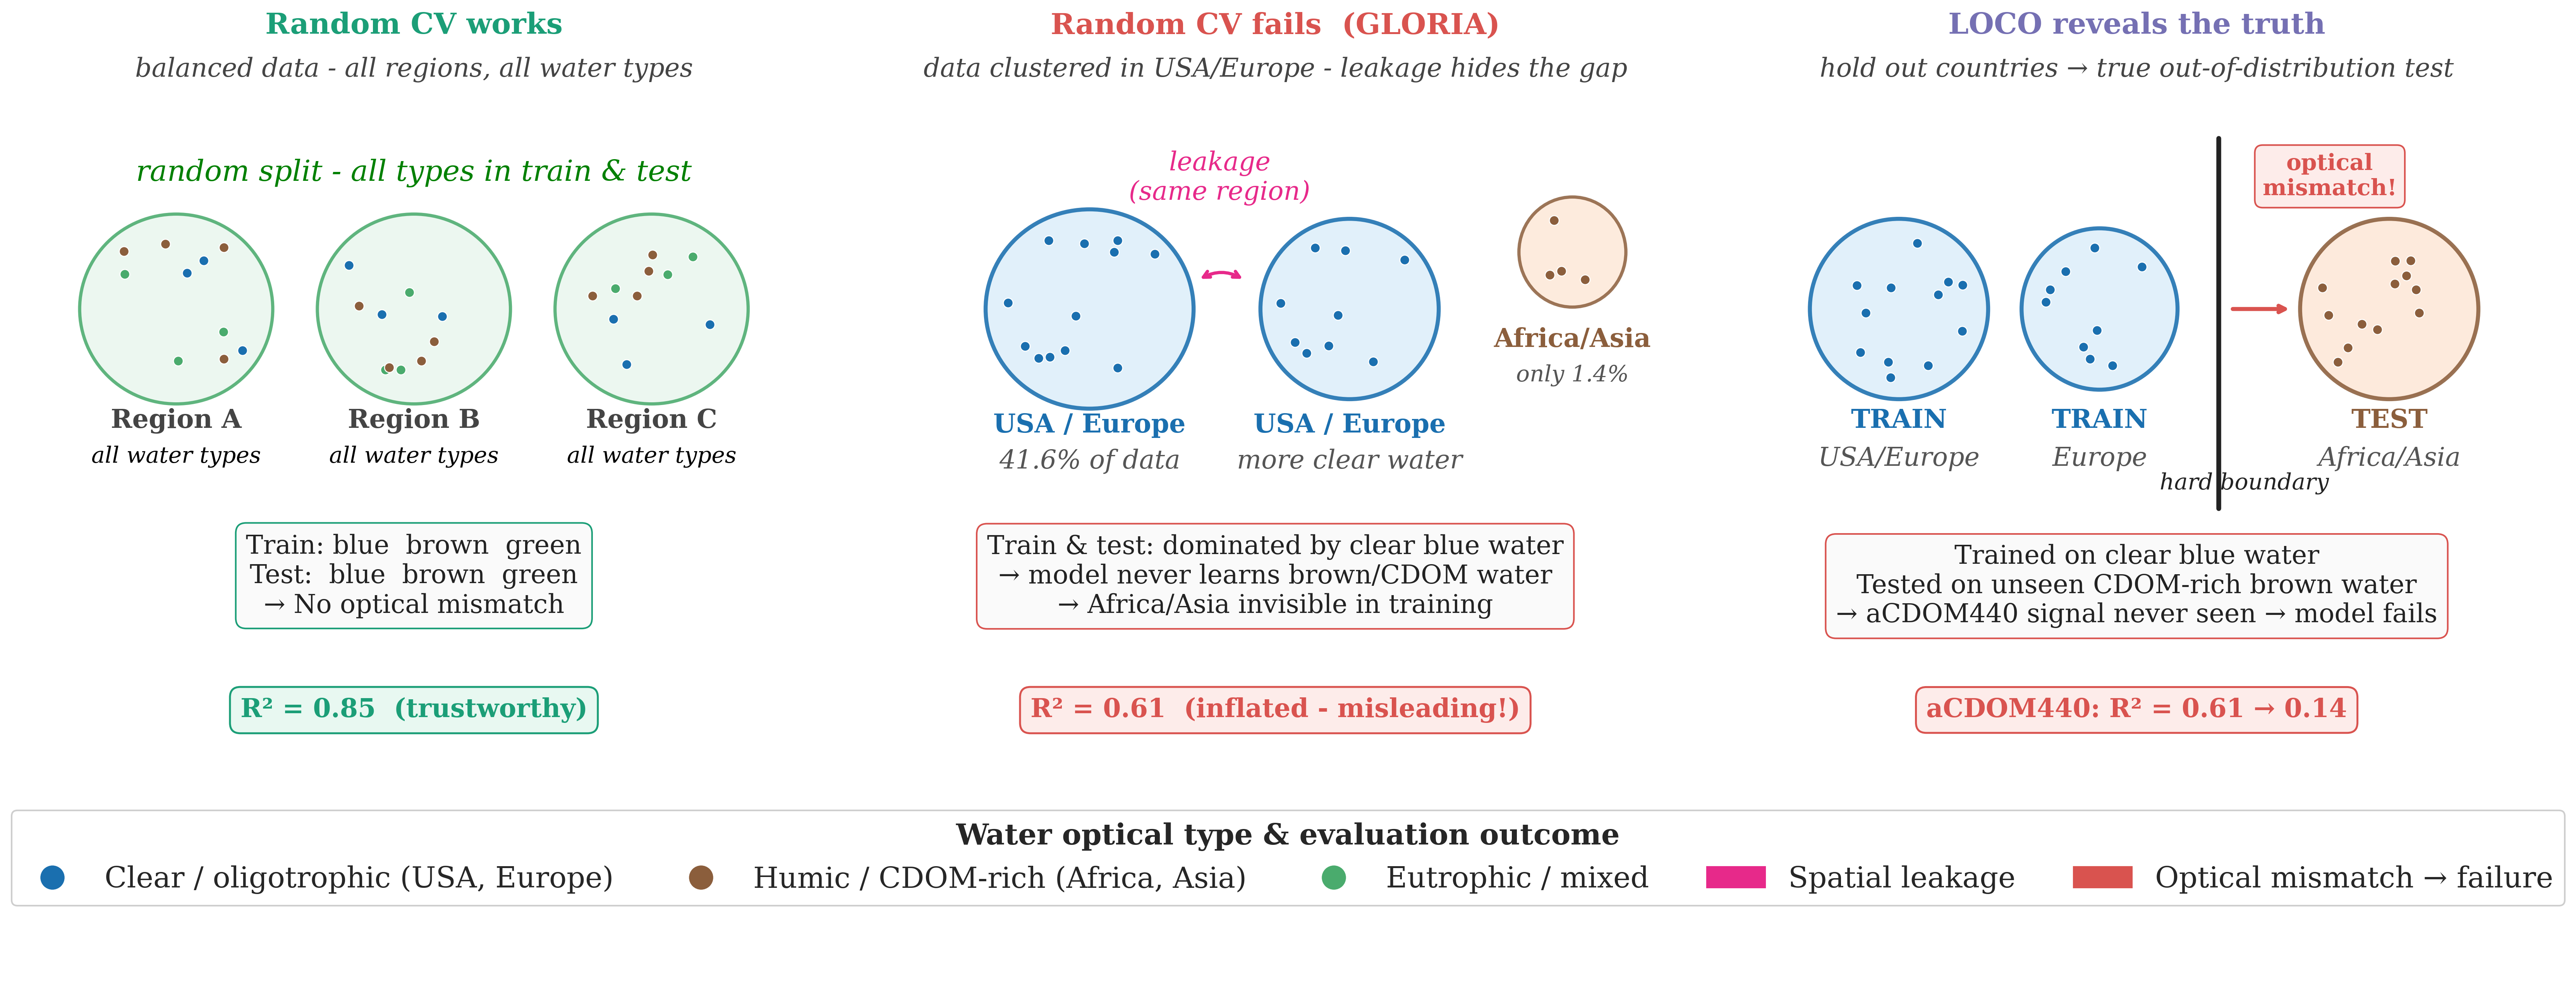

Saved: fig_leakage_loco.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({'font.family': 'serif'})

fig, axes = plt.subplots(1, 3, figsize=(22, 9), dpi=300)
# fig.suptitle('When Does Random CV Work and When Does It Fail?',
#              fontsize=20, fontweight='bold', y=1.01)

C_BLUE   = '#1a6faf'
C_BROWN  = '#8B5E3C'
C_GREEN  = '#4aab6d'
C_LEAK   = '#e7298a'
C_FAIL   = '#d9534f'
C_OK     = '#1b9e77'
C_LOCO   = '#7570b3'
C_BORDER = '#222'

WATER_ALL   = [C_BLUE, C_BROWN, C_GREEN,
               C_BLUE, C_BROWN, C_GREEN,
               C_BLUE, C_BROWN, C_GREEN, C_BROWN]
WATER_BLUE  = [C_BLUE]  * 12
WATER_BROWN = [C_BROWN] * 12

def setup_ax(ax, title, subtitle, tc):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_title(title, fontsize=18, fontweight='bold', color=tc, pad=6)
    ax.text(5, 9.65, subtitle, ha='center', fontsize=16,
            color='#444', style='italic')

def blob(ax, cx, cy, rx, ry, fc, ec, lw=2.0, alpha=0.88):
    ax.add_patch(plt.matplotlib.patches.Ellipse(
        (cx, cy), rx*2, ry*2,
        facecolor=fc, edgecolor=ec,
        linewidth=lw, alpha=alpha, zorder=2))

def dots(ax, cx, cy, colors, rx=1.0, ry=0.78, seed=0):
    rng = np.random.default_rng(seed)
    placed, attempts = 0, 0
    while placed < len(colors) and attempts < 3000:
        dx = rng.uniform(-rx*0.85, rx*0.85)
        dy = rng.uniform(-ry*0.85, ry*0.85)
        if (dx/rx)**2 + (dy/ry)**2 <= 0.92:
            ax.plot(cx+dx, cy+dy, 'o', ms=6,
                    color=colors[placed],
                    markeredgecolor='white',
                    markeredgewidth=0.6, zorder=5)
            placed += 1
        attempts += 1

def badge(ax, x, y, text, color, fc, fs=16):
    ax.text(x, y, text, ha='center', fontsize=fs,
            fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.4',
                      fc=fc, ec=color, lw=1.2))

def info_box(ax, x, y, text, ec, fs=11):
    ax.text(x, y, text, ha='center', fontsize=fs,
            color='#222', multialignment='center',
            bbox=dict(boxstyle='round,pad=0.4',
                      fc='#fafafa', ec=ec, lw=1.0))

# ═══════════════════════════════════════════════════════
# PANEL 1 — Random CV works
# ═══════════════════════════════════════════════════════
ax = axes[0]
setup_ax(ax, 'Random CV works',
         'balanced data - all regions, all water types', C_OK)

# 3 blobs at same height, well spaced
for cx, seed in [(1.8, 10), (5.0, 20), (8.2, 30)]:
    blob(ax, cx, 7.2, 1.3, 1.0, '#eaf6ee', C_GREEN)
    dots(ax, cx, 7.2, WATER_ALL, rx=1.15, ry=0.88, seed=seed)

# Labels below blobs — no overlap
for cx, lbl in [(1.8, 'Region A'), (5.0, 'Region B'), (8.2, 'Region C')]:
    ax.text(cx, 5.95, lbl, ha='center', fontsize=16,
            fontweight='bold', color='#444')
    ax.text(cx, 5.58, 'all water types', ha='center',
            fontsize=14, color='black', style='italic')

# Random split label above blobs
ax.text(5.0, 8.55, 'random split - all types in train & test',
        ha='center', fontsize=18, color='green', style='italic')
# ax.plot([2.0, 8.0], [8.3, 8.3], color='#ccc',
#         linewidth=1.0, linestyle='--')

info_box(ax, 5.0, 4.0,
         'Train: blue  brown  green\n'
         'Test:  blue  brown  green\n'
         '→ No optical mismatch', C_OK, fs=16)

badge(ax, 5.0, 2.9,
      'R² = 0.85  (trustworthy)', C_OK, '#e8f8f1', fs=16)

# ═══════════════════════════════════════════════════════
# PANEL 2 — Random CV fails (GLORIA)
# ═══════════════════════════════════════════════════════
ax = axes[1]
setup_ax(ax, 'Random CV fails  (GLORIA)',
         'data clustered in USA/Europe - leakage hides the gap', C_FAIL)

# Two large blue blobs
blob(ax, 2.5, 7.2, 1.4, 1.05, '#ddeefa', C_BLUE, lw=2.5)
dots(ax, 2.5, 7.2, WATER_BLUE, rx=1.3, ry=0.95, seed=12)
ax.text(2.5, 5.9, 'USA / Europe', ha='center', fontsize=16,
        fontweight='bold', color=C_BLUE)
ax.text(2.5, 5.52, '41.6% of data', ha='center',
        fontsize=16, color='#555', style='italic')

blob(ax, 6.0, 7.2, 1.2, 0.95, '#ddeefa', C_BLUE, lw=2.5)
dots(ax, 6.0, 7.2, WATER_BLUE[:9], rx=1.1, ry=0.85, seed=12)
ax.text(6.0, 5.9, 'USA / Europe', ha='center', fontsize=16,
        fontweight='bold', color=C_BLUE)
ax.text(6.0, 5.52, 'more clear water', ha='center',
        fontsize=16, color='#555', style='italic')

# Small Africa blob — top right, clear space
blob(ax, 9.0, 7.8, 0.72, 0.58, '#fde8d8', C_BROWN, lw=2.0, alpha=0.85)
dots(ax, 9.0, 7.8, [C_BROWN]*4, rx=0.58, ry=0.44, seed=12)
ax.text(9.0, 6.8, 'Africa/Asia', ha='center', fontsize=16,
        fontweight='bold', color=C_BROWN)
ax.text(9.0, 6.44, 'only 1.4%', ha='center',
        fontsize=14, color='#555', style='italic')

# Leakage arrow between two blue blobs
ax.annotate('', xy=(4.6, 7.5), xytext=(3.95, 7.5),
            arrowprops=dict(arrowstyle='<->', color=C_LEAK,
                            lw=2.0, connectionstyle='arc3,rad=-0.3'))
ax.text(4.25, 8.35, 'leakage\n(same region)',
        ha='center', fontsize=16, color=C_LEAK,
        style='italic', multialignment='center')

info_box(ax, 5.0, 4.0,
         'Train & test: dominated by clear blue water\n'
         '→ model never learns brown/CDOM water\n'
         '→ Africa/Asia invisible in training', C_FAIL, fs=16)

badge(ax, 5.0, 2.9,
      'R² = 0.61  (inflated - misleading!)',
      C_FAIL, '#fdecea', fs=16)

# ═══════════════════════════════════════════════════════
# PANEL 3 — LOCO reveals the truth
# ═══════════════════════════════════════════════════════
ax = axes[2]
setup_ax(ax, 'LOCO reveals the truth',
         'hold out countries → true out-of-distribution test', C_LOCO)

# TRAIN blobs left of boundary
blob(ax, 1.8, 7.2, 1.2, 0.95, '#ddeefa', C_BLUE, lw=2.5)
dots(ax, 1.8, 7.2, WATER_BLUE, rx=1.1, ry=0.85, seed=21)
ax.text(1.8, 5.95, 'TRAIN', ha='center', fontsize=16,
        fontweight='bold', color=C_BLUE)
ax.text(1.8, 5.55, 'USA/Europe', ha='center',
        fontsize=16, color='#555', style='italic')

blob(ax, 4.5, 7.2, 1.05, 0.85, '#ddeefa', C_BLUE, lw=2.5)
dots(ax, 4.5, 7.2, WATER_BLUE[:9], rx=0.95, ry=0.78, seed=22)
ax.text(4.5, 5.95, 'TRAIN', ha='center', fontsize=16,
        fontweight='bold', color=C_BLUE)
ax.text(4.5, 5.55, 'Europe', ha='center',
        fontsize=16, color='#555', style='italic')

# Hard boundary — centred
ax.plot([6.1, 6.1], [5.1, 9.0], color=C_BORDER,
        linewidth=3.0, zorder=6, solid_capstyle='round')
ax.text(6.45, 5.3, 'hard boundary',
        ha='center', fontsize=14, color=C_BORDER, style='italic')

# TEST blob right of boundary
blob(ax, 8.4, 7.2, 1.2, 0.95, '#fde8d8', C_BROWN, lw=2.5)
dots(ax, 8.4, 7.2, WATER_BROWN, rx=1.1, ry=0.85, seed=23)
ax.text(8.4, 5.95, 'TEST', ha='center', fontsize=16,
        fontweight='bold', color=C_BROWN)
ax.text(8.4, 5.55, 'Africa/Asia', ha='center',
        fontsize=16, color='#555', style='italic')

# Optical mismatch arrow
ax.annotate('', xy=(7.1, 7.2), xytext=(6.25, 7.2),
            arrowprops=dict(arrowstyle='->', color=C_FAIL, lw=2.5))
ax.text(7.6, 8.4, 'optical\nmismatch!',
        ha='center', fontsize=14, color=C_FAIL,
        fontweight='bold', multialignment='center',
        bbox=dict(boxstyle='round,pad=0.35',
                  fc='#fdecea', ec=C_FAIL, lw=1.0))

info_box(ax, 5.0, 3.9,
         'Trained on clear blue water\n'
         'Tested on unseen CDOM-rich brown water\n'
         '→ aCDOM440 signal never seen → model fails', C_FAIL, fs=16)

badge(ax, 5.0, 2.9,
      'aCDOM440: R² = 0.61 → 0.14',
      C_FAIL, '#fdecea', fs=16)

# ── Legend ───────────────────────────────────────────────
leg = fig.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=C_BLUE,
               markersize=16, label='Clear / oligotrophic (USA, Europe)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=C_BROWN,
               markersize=16, label='Humic / CDOM-rich (Africa, Asia)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=C_GREEN,
               markersize=16, label='Eutrophic / mixed'),
    mpatches.Patch(color=C_LEAK, label='Spatial leakage'),
    mpatches.Patch(color=C_FAIL, label='Optical mismatch → failure'),
], loc='lower center', fontsize=18,
   framealpha=0.95, edgecolor='#ccc',
   bbox_to_anchor=(0.5, 0.1), ncol=5,
   title='Water optical type & evaluation outcome',
   title_fontsize=18)


leg.get_title().set_fontweight('bold')
plt.tight_layout(pad=2.0)
plt.savefig(OUT / 'fig_leakage_loco.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_leakage_loco.png')